# Bayesian modeling

In [ ]:
#!/usr/bin/env python3
"""
Bayesian Hierarchical Model - THREE SEPARATE ANALYSES
Non-Immune | Immune Fine | Immune Coarse

"""

import os
import gc
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# CONFIGURATION
# ==============================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"
ROOT = f"{BASE}/stabl_fast/signature_level"
BMI_PATH = "/content/drive/MyDrive/BayesPrism/data/sample_id_with_BMI.csv"

# Bayesian sampling parameters
N_TUNE = 2000
N_SAMPLES = 2000
N_CHAINS = 4
TARGET_ACCEPT = 0.99

# ==============================================================================
# COMPARTMENT-SPECIFIC PRIOR CONFIGURATIONS
# ==============================================================================

PRIOR_CONFIGS = {
    'nonimmune': {
        'name': 'Non-Immune',
        'celltype_sigma': 0.20,
        'feature_sigma': 0.30,
        'baseline_sigma': 1.5,
        'obs_sigma': 1.0,
        'rationale': 'CAFs and endothelial cells show robust BMI-related changes'
    },
    'immune_coarse': {
        'name': 'Immune Coarse',
        'celltype_sigma': 0.25,
        'feature_sigma': 0.40,
        'baseline_sigma': 1.5,
        'obs_sigma': 1.0,
        'rationale': 'Broad immune populations show moderate effect sizes'
    },
    'immune_fine': {
        'name': 'Immune Fine',
        'celltype_sigma': 0.18,
        'feature_sigma': 0.28,
        'baseline_sigma': 1.5,
        'obs_sigma': 1.0,
        'rationale': 'Granular states require strong pooling to detect real signal over noise'
    }
}

# ==============================================================================
# THREE SEPARATE ANALYSIS CONFIGURATIONS
# ==============================================================================

ANALYSES = {
    'nonimmune': {
        'name': 'Non-Immune',
        'description': 'Tumor microenvironment (non-immune cells)',
        'target': {"name": "non_immune/type_level", "display": "Non-Immune"},
        'output_dir': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
        'color': '#8B4513',
        'priors': PRIOR_CONFIGS['nonimmune']
    },
    'immune_fine': {
        'name': 'Immune Fine',
        'description': 'Detailed immune cell states',
        'target': {"name": "immune_fine/state_level", "display": "Immune Fine"},
        'output_dir': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
        'color': '#4169E1',
        'priors': PRIOR_CONFIGS['immune_fine']
    },
    'immune_coarse': {
        'name': 'Immune Coarse',
        'description': 'Broad immune cell types',
        'target': {"name": "immune_course/type_level", "display": "Immune Coarse"},
        'output_dir': f"{BASE}/bayesian_hierarchical_3group_immune_coarse",
        'color': '#32CD32',
        'priors': PRIOR_CONFIGS['immune_coarse']
    }
}

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def to_base_id_any(x):
    if pd.isna(x): return np.nan
    first = str(x).split(";")[0].strip()
    parts = first.split("-")
    return f"{parts[0]}-{parts[1]}" if len(parts) >= 2 else first

def make_bmi_group(v):
    try: v = float(v)
    except: return np.nan
    if v < 18.5: return "underweight"
    if v < 25:   return "normal_weight"
    if v < 30:   return "overweight"
    return "obese"

def parse_feature(feature):
    if "||" in feature:
        parts = feature.split("||", 1)
        return parts[0].strip().replace("_", " "), parts[1].strip()
    return "Unknown", feature

# ==============================================================================
# DATA LOADING
# ==============================================================================

def load_data(target_info, analysis_name):
    """Load data for specific analysis - UPDATED TO USE STABL UNION REBUILDS"""
    print(f"\n{'='*80}")
    print(f"LOADING DATA: {analysis_name}")
    print(f"{'='*80}")

    # Load BMI data
    print("\nLoading BMI data...")
    bmi = pd.read_csv(BMI_PATH)
    bmi.columns = [c.lower() for c in bmi.columns]
    bmi["sample_id"] = bmi["sample_id"].astype(str)
    bmi["bmi"] = pd.to_numeric(bmi["bmi"], errors="coerce")
    bmi["base_sample_id"] = bmi["sample_id"].map(to_base_id_any)
    bmi["bmi_group"] = bmi["bmi"].map(make_bmi_group)

    print("\nSample sizes per BMI group:")
    for group in ['normal_weight', 'overweight', 'obese']:
        n = (bmi['bmi_group'] == group).sum()
        print(f"  {group}: n={n}")

    # Load signature data - UPDATED PATH TO STABL UNION REBUILDS
    target_group = target_info["name"]
    z_file = f"{ROOT}/{target_group}/union_rebuilds/union_long.csv"

    if not os.path.exists(z_file):
        raise FileNotFoundError(f"File not found: {z_file}")

    print(f"\n Loading: {z_file}")
    df = pd.read_csv(z_file)
    df.columns = [c.strip() for c in df.columns]
    df["feature"] = df["CellType"].astype(str) + "||" + df["Signature"].astype(str)
    df["base_sample_id"] = df["Sample"].astype(str).map(to_base_id_any)
    df["Z"] = pd.to_numeric(df["Z"], errors="coerce")
    df['target_group'] = target_group
    df['target_display'] = target_info['display']

    # Merge with BMI
    merged = df.merge(
        bmi[["base_sample_id", "bmi", "bmi_group"]],
        on="base_sample_id", how="inner"
    ).dropna(subset=["Z", "bmi"])

    merged = merged[merged["bmi_group"].isin(["normal_weight", "overweight", "obese"])]
    merged[['cell_type', 'signature']] = merged['feature'].apply(
        lambda x: pd.Series(parse_feature(x))
    )

    print(f"\n Loaded {target_info['display']}:")
    print(f"   Observations: {len(merged)}")
    print(f"   Features: {merged['feature'].nunique()}")
    print(f"   Cell types: {merged['cell_type'].nunique()}")
    print(f"   Signatures: {merged['signature'].nunique()}")

    # Show cell type distribution
    print(f"\n Cell type distribution:")
    ct_counts = merged.groupby('cell_type')['feature'].nunique().sort_values(ascending=False)
    for ct, count in ct_counts.head(10).items():
        print(f"   {ct}: {count} signatures")
    if len(ct_counts) > 10:
        print(f"   ... and {len(ct_counts) - 10} more cell types")

    return merged

def prepare_hierarchical_data(merged_data):
    """Prepare data for hierarchical model with safety checks"""
    merged_data = merged_data.copy()
    bmi_map = {'normal_weight': 0, 'overweight': 1, 'obese': 2}
    merged_data['bmi_idx'] = merged_data['bmi_group'].map(bmi_map)

    # Sort to ensure consistency
    merged_data = merged_data.sort_values(['cell_type', 'feature', 'base_sample_id'])

    # Get unique lists - sorted alphabetically for consistency
    features = sorted(merged_data['feature'].unique())
    cell_types = sorted(merged_data['cell_type'].unique())

    # Create Mappings
    feature_to_idx = {f: i for i, f in enumerate(features)}
    celltype_to_idx = {ct: i for i, ct in enumerate(cell_types)}

    merged_data['feature_idx'] = merged_data['feature'].map(feature_to_idx)
    merged_data['celltype_idx'] = merged_data['cell_type'].map(celltype_to_idx)


    mapping_df = merged_data[['feature_idx', 'celltype_idx']].drop_duplicates().sort_values('feature_idx')
    feature_to_celltype = mapping_df['celltype_idx'].values

    print(f"\n Hierarchical structure:")
    print(f"   {len(features)} features")
    print(f"   {len(cell_types)} cell types")
    print(f"   Features per cell type: {len(features)/len(cell_types):.1f} avg")
    print(f"   Mapping shape check: {feature_to_celltype.shape}")

    return {
        'data': merged_data,
        'n_obs': len(merged_data),
        'n_features': len(features),
        'n_celltypes': len(cell_types),
        'feature_names': features,
        'celltype_names': cell_types,
        'feature_to_idx': feature_to_idx,
        'celltype_to_idx': celltype_to_idx,
        'feature_to_celltype': feature_to_celltype
    }

# ==============================================================================
# EMPIRICAL VARIANCE ESTIMATION
# ==============================================================================

def estimate_empirical_variance(data_dict, prior_config):
    """Estimate empirical effect sizes to validate prior choices"""
    print(f"\n Empirical variance estimation for {prior_config['name']}...")

    data = data_dict['data']

    # Simple linear model per feature
    effects_ow = []
    effects_ob = []

    for feature in data_dict['feature_names']:
        feat_data = data[data['feature'] == feature].copy()

        if len(feat_data) < 10:
            continue

        # Dummy coding
        feat_data['is_ow'] = (feat_data['bmi_group'] == 'overweight').astype(int)
        feat_data['is_ob'] = (feat_data['bmi_group'] == 'obese').astype(int)

        # Simple regression
        from sklearn.linear_model import LinearRegression
        X = feat_data[['is_ow', 'is_ob']].values
        y = feat_data['Z'].values

        try:
            model = LinearRegression()
            model.fit(X, y)
            effects_ow.append(model.coef_[0])
            effects_ob.append(model.coef_[1])
        except:
            continue

    effects_ow = np.array(effects_ow)
    effects_ob = np.array(effects_ob)

    print(f"\n   Empirical effect size distribution (Overweight vs Normal):")
    print(f"      Mean: {np.mean(effects_ow):.3f}")
    print(f"      SD: {np.std(effects_ow):.3f}")
    print(f"      95% range: [{np.percentile(effects_ow, 2.5):.3f}, {np.percentile(effects_ow, 97.5):.3f}]")

    print(f"\n   Empirical effect size distribution (Obese vs Normal):")
    print(f"      Mean: {np.mean(effects_ob):.3f}")
    print(f"      SD: {np.std(effects_ob):.3f}")
    print(f"      95% range: [{np.percentile(effects_ob, 2.5):.3f}, {np.percentile(effects_ob, 97.5):.3f}]")

    # Compare to chosen priors
    empirical_sigma = np.std(effects_ow)
    chosen_sigma = prior_config['celltype_sigma']

    print(f"\n    Prior validation:")
    print(f"      Empirical SD: {empirical_sigma:.3f}")
    print(f"      Chosen cell-type σ: {chosen_sigma:.3f}")

    if chosen_sigma < empirical_sigma * 0.5:
        print(f"        WARNING: Prior may be TOO STRONG (much tighter than data)")
    elif chosen_sigma > empirical_sigma * 2.0:
        print(f"        WARNING: Prior may be TOO WEAK (much wider than data)")
    else:
        print(f"       Prior looks reasonable (within 0.5-2x of empirical)")

    return {
        'effects_ow': effects_ow,
        'effects_ob': effects_ob,
        'empirical_sigma': empirical_sigma
    }

# ==============================================================================
# PRIOR PREDICTIVE CHECK
# ==============================================================================

def run_prior_predictive_check(model, data_dict, prior_config, n_samples=1000):
    """Check if priors generate reasonable effect sizes BEFORE seeing data"""
    print(f"\n Prior Predictive Check for {prior_config['name']}...")

    with model:
        prior_pred = pm.sample_prior_predictive(samples=n_samples, random_seed=42)

    # Extract prior samples
    celltype_ow = prior_pred.prior['celltype_effect_overweight'].values.flatten()
    celltype_ob = prior_pred.prior['celltype_effect_obese'].values.flatten()
    feature_ow = prior_pred.prior['feature_effect_overweight'].values.flatten()
    feature_ob = prior_pred.prior['feature_effect_obese'].values.flatten()

    print(f"\n Prior predictions:")
    print(f"   Cell-type effects (Overweight):")
    print(f"      95% range: [{np.percentile(celltype_ow, 2.5):.3f}, {np.percentile(celltype_ow, 97.5):.3f}]")
    print(f"      Mean: {np.mean(celltype_ow):.3f}, SD: {np.std(celltype_ow):.3f}")

    print(f"   Feature effects (Overweight):")
    print(f"      95% range: [{np.percentile(feature_ow, 2.5):.3f}, {np.percentile(feature_ow, 97.5):.3f}]")
    print(f"      Mean: {np.mean(feature_ow):.3f}, SD: {np.std(feature_ow):.3f}")

    # CHECK: Are these biologically plausible?
    extreme_features = np.sum(np.abs(feature_ow) > 1.5)
    pct_extreme = (extreme_features / len(feature_ow)) * 100

    print(f"\n  Prior sanity check:")
    print(f"   Features with |effect| > 1.5: {extreme_features}/{len(feature_ow)} ({pct_extreme:.1f}%)")
    if pct_extreme > 10:
        print(f"     WARNING: Priors may be too weak (>10% extreme values)")
    elif pct_extreme < 1:
        print(f"     WARNING: Priors may be too strong (<1% extreme values)")
    else:
        print(f"    Priors look reasonable (1-10% extreme values)")

    return prior_pred

# ==============================================================================
# MODEL BUILDING
# ==============================================================================

def build_hierarchical_model(data_dict, prior_config):
    """Build hierarchical Bayesian model"""
    data = data_dict['data']
    print(f"\n Building hierarchical model for {prior_config['name']}...")
    print(f"   Rationale: {prior_config['rationale']}")
    print(f"   Cell-type σ: {prior_config['celltype_sigma']}")
    print(f"   Feature σ: {prior_config['feature_sigma']}")
    print(f"   Baseline σ: {prior_config['baseline_sigma']}")

    # Define Coordinates
    coords = {
        "celltype": data_dict['celltype_names'],
        "feature": data_dict['feature_names'],
        "obs_id": data.index
    }

    with pm.Model(coords=coords) as model:

        # Data containers
        feature_idx_data = pm.Data("feature_idx_data", data['feature_idx'].values, dims="obs_id")
        bmi_idx_data = pm.Data("bmi_idx_data", data['bmi_idx'].values, dims="obs_id")
        observed_data = pm.Data("observed_data", data['Z'].values, dims="obs_id")

        # Map features to cell types
        feature_map = pm.Data("feature_to_celltype_map", data_dict['feature_to_celltype'], dims="feature")

        # Cell-type level effects
        celltype_effect_overweight = pm.Normal(
            'celltype_effect_overweight',
            mu=0,
            sigma=prior_config['celltype_sigma'],
            dims="celltype"
        )
        celltype_effect_obese = pm.Normal(
            'celltype_effect_obese',
            mu=0,
            sigma=prior_config['celltype_sigma'],
            dims="celltype"
        )

        # Feature-level variance within cell types
        feature_sigma_overweight = pm.HalfNormal(
            'feature_sigma_overweight',
            sigma=prior_config['feature_sigma'],
            dims="celltype"
        )
        feature_sigma_obese = pm.HalfNormal(
            'feature_sigma_obese',
            sigma=prior_config['feature_sigma'],
            dims="celltype"
        )

        # Non-centered: Feature-level deviations
        feature_deviation_overweight_raw = pm.Normal(
            'feature_deviation_overweight_raw', mu=0, sigma=1, dims="feature"
        )
        feature_deviation_obese_raw = pm.Normal(
            'feature_deviation_obese_raw', mu=0, sigma=1, dims="feature"
        )

        # Non-centered: Feature-level effects
        feature_effect_overweight = pm.Deterministic(
            'feature_effect_overweight',
            celltype_effect_overweight[feature_map] +
            feature_deviation_overweight_raw * feature_sigma_overweight[feature_map],
            dims="feature"
        )

        feature_effect_obese = pm.Deterministic(
            'feature_effect_obese',
            celltype_effect_obese[feature_map] +
            feature_deviation_obese_raw * feature_sigma_obese[feature_map],
            dims="feature"
        )

        # Baseline
        feature_baseline = pm.Normal(
            'feature_baseline',
            mu=0,
            sigma=prior_config['baseline_sigma'],
            dims="feature"
        )

        # Observation noise
        sigma_obs = pm.HalfNormal('sigma_obs', sigma=prior_config['obs_sigma'])

        # Likelihood
        mu = pm.Deterministic(
            'mu',
            feature_baseline[feature_idx_data] +
            feature_effect_overweight[feature_idx_data] * pm.math.eq(bmi_idx_data, 1) +
            feature_effect_obese[feature_idx_data] * pm.math.eq(bmi_idx_data, 2),
            dims="obs_id"
        )

        pm.Normal('y_obs', mu=mu, sigma=sigma_obs, observed=observed_data, dims="obs_id")

        # Derived quantity
        pm.Deterministic(
            'feature_effect_obese_vs_overweight',
            feature_effect_obese - feature_effect_overweight,
            dims="feature"
        )

    print(f" Model built with compartment-specific priors:")
    print(f"   Parameters: {len(model.free_RVs)}")
    print(f"   Observations: {len(data)}")
    print(f"   Coordinates: {list(coords.keys())}")

    return model

# ==============================================================================
# SAMPLING
# ==============================================================================

def sample_hierarchical_model(model):
    """Sample from the model"""
    print(f"\n Sampling posterior...")
    print(f"   Tuning: {N_TUNE} iterations")
    print(f"   Sampling: {N_SAMPLES} iterations")
    print(f"   Chains: {N_CHAINS}")
    print(f"   Target accept: {TARGET_ACCEPT}")

    with model:
        trace = pm.sample(
            draws=N_SAMPLES,
            tune=N_TUNE,
            chains=N_CHAINS,
            cores=N_CHAINS,
            target_accept=TARGET_ACCEPT,
            return_inferencedata=True,
            progressbar=True
        )

    print(f"\n Sampling complete!")
    return trace

# ==============================================================================
# POSTERIOR PREDICTIVE CHECK
# ==============================================================================

def generate_ppc(model, trace, data_dict):
    """Generate posterior predictive samples"""
    print("\n Generating posterior predictive check...")

    with model:
        ppc = pm.sample_posterior_predictive(
            trace,
            var_names=['y_obs'],
            random_seed=42,
            progressbar=True
        )

        trace.extend(ppc)

        print(f"\n PPC generated!")
        print(f"   Shape: {ppc.posterior_predictive['y_obs'].shape}")

        # Quick validation
        observed = data_dict['data']['Z'].values
        predicted = ppc.posterior_predictive['y_obs'].values

        obs_mean = observed.mean()
        obs_sd = observed.std()
        pred_mean = predicted.mean()
        pred_sd = predicted.std()

        print(f"\n Model fit check:")
        print(f"   Observed  - Mean: {obs_mean:.3f}, SD: {obs_sd:.3f}")
        print(f"   Predicted - Mean: {pred_mean:.3f}, SD: {pred_sd:.3f}")
        print(f"   Mean diff: {abs(obs_mean - pred_mean):.3f} "
              f"({' Good' if abs(obs_mean - pred_mean) < 0.5 else 'Check'})")
        print(f"   SD diff: {abs(obs_sd - pred_sd):.3f} "
              f"({' Good' if abs(obs_sd - pred_sd) < 0.5 else 'Check'})")

    return trace

# ==============================================================================
# RESULTS SUMMARIZATION
# ==============================================================================

def summarize_results(trace, data_dict):
    """Extract summary statistics"""
    print("\n Extracting summaries...")

    summary = az.summary(
        trace,
        var_names=['feature_effect_overweight', 'feature_effect_obese',
                   'feature_effect_obese_vs_overweight'],
        hdi_prob=0.95
    )

    results = []
    for i, feature in enumerate(data_dict['feature_names']):
        celltype_idx = data_dict['feature_to_celltype'][i]
        celltype = data_dict['celltype_names'][celltype_idx]

        ow_idx = f'feature_effect_overweight[{feature}]'
        ob_idx = f'feature_effect_obese[{feature}]'
        ob_ow_idx = f'feature_effect_obese_vs_overweight[{feature}]'

        ow_mean = summary.loc[ow_idx, 'mean']
        ow_low = summary.loc[ow_idx, 'hdi_2.5%']
        ow_high = summary.loc[ow_idx, 'hdi_97.5%']

        ob_mean = summary.loc[ob_idx, 'mean']
        ob_low = summary.loc[ob_idx, 'hdi_2.5%']
        ob_high = summary.loc[ob_idx, 'hdi_97.5%']

        ob_ow_mean = summary.loc[ob_ow_idx, 'mean']
        ob_ow_low = summary.loc[ob_ow_idx, 'hdi_2.5%']
        ob_ow_high = summary.loc[ob_ow_idx, 'hdi_97.5%']

        post_ow = trace.posterior['feature_effect_overweight'].sel(feature=feature).values.flatten()
        post_ob = trace.posterior['feature_effect_obese'].sel(feature=feature).values.flatten()
        post_ob_ow = trace.posterior['feature_effect_obese_vs_overweight'].sel(feature=feature).values.flatten()

        results.append({
            'feature': feature,
            'cell_type': celltype,
            'overweight_vs_normal_mean': ow_mean,
            'overweight_vs_normal_hdi_low': ow_low,
            'overweight_vs_normal_hdi_high': ow_high,
            'overweight_vs_normal_prob_positive': np.mean(post_ow > 0),
            'overweight_vs_normal_prob_sig': np.mean(np.abs(post_ow) > 0.1),
            'obese_vs_normal_mean': ob_mean,
            'obese_vs_normal_hdi_low': ob_low,
            'obese_vs_normal_hdi_high': ob_high,
            'obese_vs_normal_prob_positive': np.mean(post_ob > 0),
            'obese_vs_normal_prob_sig': np.mean(np.abs(post_ob) > 0.1),
            'obese_vs_overweight_mean': ob_ow_mean,
            'obese_vs_overweight_hdi_low': ob_ow_low,
            'obese_vs_overweight_hdi_high': ob_ow_high,
            'obese_vs_overweight_prob_positive': np.mean(post_ob_ow > 0),
            'obese_vs_overweight_prob_sig': np.mean(np.abs(post_ob_ow) > 0.1),
        })

    print(f" Summaries extracted for {len(results)} features")

    return pd.DataFrame(results)

# ==============================================================================
# SAVE OUTPUTS
# ==============================================================================

def save_outputs(trace, results_df, data_dict, output_dir, prior_config):
    """Save all outputs"""
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n Saving outputs to: {output_dir}")

    # Save trace
    trace_path = os.path.join(output_dir, 'posterior_trace.nc')

    if os.path.exists(trace_path):
        try:
            os.remove(trace_path)
        except Exception as e:
            print(f"     Could not remove old trace: {e}")

    trace.to_netcdf(trace_path)
    print(f"    Trace: posterior_trace.nc")

    # Save results
    results_path = os.path.join(output_dir, 'bayesian_results_3group.csv')
    results_df.to_csv(results_path, index=False)
    print(f"    Results: bayesian_results_3group.csv")

    # Save mappings
    celltype_mapping = pd.DataFrame({
        'celltype_idx': range(data_dict['n_celltypes']),
        'celltype_name': list(data_dict['celltype_names'])
    })
    celltype_path = os.path.join(output_dir, 'celltype_mapping.csv')
    celltype_mapping.to_csv(celltype_path, index=False)
    print(f"    Cell types: celltype_mapping.csv")

    feature_mapping = pd.DataFrame({
        'feature_idx': range(data_dict['n_features']),
        'feature_name': list(data_dict['feature_names']),
        'celltype_idx': data_dict['feature_to_celltype']
    })
    feature_path = os.path.join(output_dir, 'feature_mapping.csv')
    feature_mapping.to_csv(feature_path, index=False)
    print(f"    Features: feature_mapping.csv")

    # Save prior configuration
    prior_config_df = pd.DataFrame([{
        'compartment': prior_config['name'],
        'celltype_sigma': prior_config['celltype_sigma'],
        'feature_sigma': prior_config['feature_sigma'],
        'baseline_sigma': prior_config['baseline_sigma'],
        'obs_sigma': prior_config['obs_sigma'],
        'rationale': prior_config['rationale']
    }])
    prior_path = os.path.join(output_dir, 'prior_configuration.csv')
    prior_config_df.to_csv(prior_path, index=False)
    print(f"    Prior config: prior_configuration.csv")

# ==============================================================================
# VARIANCE DECOMPOSITION
# ==============================================================================

def variance_decomposition(trace, data_dict, prior_config):
    """Proper variance decomposition"""
    print(f"\n Variance Decomposition for {prior_config['name']}:")

    for comparison in ['overweight', 'obese']:
        celltype_var = f'celltype_effect_{comparison}'
        celltype_effects = trace.posterior[celltype_var].values.mean(axis=(0, 1))

        feature_var = f'feature_effect_{comparison}'
        feature_effects = trace.posterior[feature_var].values.mean(axis=(0, 1))

        sigma_var = f'feature_sigma_{comparison}'
        feature_sigmas = trace.posterior[sigma_var].values.mean(axis=(0, 1))

        var_between_celltypes = np.var(celltype_effects)

        feature_to_celltype = data_dict['feature_to_celltype']
        within_vars = []
        for ct_idx in range(data_dict['n_celltypes']):
            feat_mask = feature_to_celltype == ct_idx
            if np.sum(feat_mask) > 0:
                ct_feature_effects = feature_effects[feat_mask]
                ct_mean = celltype_effects[ct_idx]
                within_var = np.mean((ct_feature_effects - ct_mean)**2)
                within_vars.append(within_var)

        var_within_celltypes = np.mean(within_vars)
        total_var = var_between_celltypes + var_within_celltypes
        icc = var_between_celltypes / total_var if total_var > 0 else 0
        observed_total_var = np.var(feature_effects)

        print(f"\n   {comparison.capitalize()}:")
        print(f"      Between cell-type variance: {var_between_celltypes:.6f}")
        print(f"      Within cell-type variance:  {var_within_celltypes:.6f}")
        print(f"      Total variance (sum):       {total_var:.6f}")
        print(f"      Observed total variance:    {observed_total_var:.6f}")
        print(f"      ICC (between/total):        {icc:.3f}")

        if icc > 0.7:
            print(f"       STRONG hierarchy: {icc*100:.1f}% of variance is between cell types")
        elif icc > 0.4:
            print(f"        MODERATE hierarchy: {icc*100:.1f}% of variance is between cell types")
        else:
            print(f"       WEAK hierarchy: Only {icc*100:.1f}% of variance is between cell types")

        avg_sigma = np.mean(feature_sigmas)
        print(f"\n      Posterior feature σ (avg): {avg_sigma:.3f}")
        print(f"      Prior feature σ:           {prior_config['feature_sigma']:.3f}")
        print(f"      Shrinkage factor:          {avg_sigma / prior_config['feature_sigma']:.2f}x")

def check_shrinkage(trace, data_dict, prior_config):
    """Calculate hierarchical shrinkage"""
    print(f"\n🔍 Hierarchical Pooling Diagnostics for {prior_config['name']}:")

    for comparison in ['overweight', 'obese']:
        celltype_var = f'celltype_effect_{comparison}'
        celltype_effects = trace.posterior[celltype_var].values.mean(axis=(0, 1))

        feature_var = f'feature_effect_{comparison}'
        feature_effects = trace.posterior[feature_var].values.mean(axis=(0, 1))

        feature_to_celltype = data_dict['feature_to_celltype']

        deviations = []
        for feat_idx in range(data_dict['n_features']):
            ct_idx = feature_to_celltype[feat_idx]
            pooled = celltype_effects[ct_idx]
            feature = feature_effects[feat_idx]
            deviation = abs(feature - pooled)
            deviations.append(deviation)

        avg_deviation = np.mean(deviations)
        max_deviation = np.max(deviations)
        median_deviation = np.median(deviations)

        feature_empirical_sd = np.std(feature_effects)
        if feature_empirical_sd > 0:
            pct_at_celltype = (1 - avg_deviation / feature_empirical_sd) * 100
        else:
            pct_at_celltype = 0

        print(f"\n   {comparison.capitalize()}:")
        print(f"      Average deviation from cell-type mean: {avg_deviation:.3f}")
        print(f"      Median deviation:  {median_deviation:.3f}")
        print(f"      Maximum deviation: {max_deviation:.3f}")
        print(f"      Empirical SD of feature effects: {feature_empirical_sd:.3f}")
        print(f"      → {pct_at_celltype:.1f}% of variation captured at cell-type level")

        if pct_at_celltype > 80:
            print(f"       STRONG pooling: Features tightly grouped within cell types")
        elif pct_at_celltype > 50:
            print(f"        MODERATE pooling: Some feature-level variation remains")
        else:
            print(f"       WEAK pooling: Features behaving independently")

        large_dev = sum(1 for d in deviations if d > 0.1)
        pct_large = (large_dev / len(deviations)) * 100
        print(f"      Features with deviation >0.1: {large_dev} ({pct_large:.1f}%)")

# ==============================================================================
# CONVERGENCE DIAGNOSTICS
# ==============================================================================

def check_convergence(trace, results_df):
    """Check convergence diagnostics"""
    print(f"\n🔍 Convergence diagnostics:")

    rhat_summary = az.summary(
        trace,
        var_names=['celltype_effect_overweight', 'celltype_effect_obese']
    )
    max_rhat = rhat_summary['r_hat'].max()
    print(f"   Max R-hat: {max_rhat:.4f} "
          f"({' Converged' if max_rhat < 1.01 else '⚠️ Check convergence'})")

    ow_credible = ((results_df['overweight_vs_normal_hdi_low'] > 0) |
                   (results_df['overweight_vs_normal_hdi_high'] < 0)).sum()
    ob_credible = ((results_df['obese_vs_normal_hdi_low'] > 0) |
                   (results_df['obese_vs_normal_hdi_high'] < 0)).sum()
    ob_ow_credible = ((results_df['obese_vs_overweight_hdi_low'] > 0) |
                      (results_df['obese_vs_overweight_hdi_high'] < 0)).sum()

    print(f"\n Credible effects (HDI excludes 0):")
    print(f"   Overweight vs Normal: {ow_credible}/{len(results_df)} "
          f"({ow_credible/len(results_df)*100:.1f}%)")
    print(f"   Obese vs Normal: {ob_credible}/{len(results_df)} "
          f"({ob_credible/len(results_df)*100:.1f}%)")
    print(f"   Obese vs Overweight: {ob_ow_credible}/{len(results_df)} "
          f"({ob_ow_credible/len(results_df)*100:.1f}%)")

# ==============================================================================
# RUN SINGLE ANALYSIS
# ==============================================================================

def run_analysis(analysis_key):
    """Run a single analysis"""
    config = ANALYSES[analysis_key]
    prior_config = config['priors']

    print("\n" + "="*80)
    print(f" ANALYSIS: {config['name']}")
    print(f" {config['description']}")
    print(f" Prior strategy: {prior_config['rationale']}")
    print("="*80)

    data = load_data(config['target'], config['name'])
    data_dict = prepare_hierarchical_data(data)
    empirical = estimate_empirical_variance(data_dict, prior_config)
    model = build_hierarchical_model(data_dict, prior_config)
    prior_pred = run_prior_predictive_check(model, data_dict, prior_config)
    trace = sample_hierarchical_model(model)
    trace = generate_ppc(model, trace, data_dict)
    results_df = summarize_results(trace, data_dict)
    save_outputs(trace, results_df, data_dict, config['output_dir'], prior_config)
    check_convergence(trace, results_df)
    variance_decomposition(trace, data_dict, prior_config)
    check_shrinkage(trace, data_dict, prior_config)

    print(f"\n {config['name']} analysis complete!")
    print(f" Results saved to: {config['output_dir']}")

    del trace
    del model
    del prior_pred
    gc.collect()

    return {
        'results': results_df,
        'data_dict': data_dict,
        'config': config,
        'empirical': empirical
    }

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """Run all three analyses"""
    print("="*80)
    print("BAYESIAN HIERARCHICAL MODEL - THREE COMPARTMENTS")
    print("   USING STABL UNION REBUILDS")
    print("="*80)

    all_results = {}

    for analysis_key in ['nonimmune', 'immune_fine', 'immune_coarse']:
        try:
            results = run_analysis(analysis_key)
            all_results[analysis_key] = results
        except Exception as e:
            print(f"\n ERROR in {analysis_key}: {e}")
            import traceback
            traceback.print_exc()
            continue

    print("\n" + "="*80)
    print(" SUMMARY ACROSS ALL ANALYSES")
    print("="*80)

    for key, results in all_results.items():
        config = results['config']
        df = results['results']

        print(f"\n{config['name']}:")
        print(f"   Features: {len(df)}")
        print(f"   Cell types: {results['data_dict']['n_celltypes']}")

    print("\n ALL ANALYSES COMPLETE!")

    return all_results

if __name__ == "__main__":
    results = main()



🔬 BAYESIAN HIERARCHICAL MODEL - THREE COMPARTMENTS
   USING STABL UNION REBUILDS

🔬 ANALYSIS: Non-Immune
📝 Tumor microenvironment (non-immune cells)
🎯 Prior strategy: CAFs and endothelial cells show robust BMI-related changes

LOADING DATA: Non-Immune

📊 Loading BMI data...

Sample sizes per BMI group:
  normal_weight: n=52
  overweight: n=57
  obese: n=18

📁 Loading: /content/drive/MyDrive/new_dysfunction/stabl_fast/signature_level/non_immune/type_level/rebuilt/z_long_union_all.csv

✅ Loaded Non-Immune:
   Observations: 31623
   Features: 249
   Cell types: 15
   Signatures: 136

📊 Cell type distribution:
   FIBROBLASTS: 33 signatures
   PERICYTES SMC: 33 signatures
   TUMOR CLASSICAL: 28 signatures
   ICAF: 24 signatures
   SCHWANN: 24 signatures
   NORMAL DUCTAL: 21 signatures
   ISLET ENDOCRINE: 21 signatures
   ADIPOCYTES: 18 signatures
   APCAF: 14 signatures
   STELLATE: 10 signatures
   ... and 5 more cell types

🏗️ Hierarchical structure:
   249 features
   15 cell types
   Fe

Output()

Output()


✅ Sampling complete!

🔮 Generating posterior predictive check...



✅ PPC generated!
   Shape: (4, 2000, 31623)

📊 Model fit check:
   Observed  - Mean: -0.026, SD: 0.490
   Predicted - Mean: -0.026, SD: 0.495
   Mean diff: 0.000 (✅ Good)
   SD diff: 0.005 (✅ Good)

📊 Extracting summaries...
✅ Summaries extracted for 249 features

💾 Saving outputs to: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune
   ✅ Trace: posterior_trace.nc
   ✅ Results: bayesian_results_3group.csv
   ✅ Cell types: celltype_mapping.csv
   ✅ Features: feature_mapping.csv
   ✅ Prior config: prior_configuration.csv

🔍 Convergence diagnostics:
   Max R-hat: 1.0000 (✅ Converged)

📊 Credible effects (HDI excludes 0):
   Overweight vs Normal: 137/249 (55.0%)
   Obese vs Normal: 80/249 (32.1%)
   Obese vs Overweight: 33/249 (13.3%)

📊 Variance Decomposition for Non-Immune:

   Overweight:
      Between cell-type variance: 0.011999
      Within cell-type variance:  0.000610
      Total variance (sum):       0.012609
      Observed total variance:    0.006679


Output()

Output()


✅ Sampling complete!

🔮 Generating posterior predictive check...



✅ PPC generated!
   Shape: (4, 373, 19812)

📊 Model fit check:
   Observed  - Mean: -0.022, SD: 0.549
   Predicted - Mean: -0.022, SD: 0.554
   Mean diff: 0.000 (✅ Good)
   SD diff: 0.005 (✅ Good)

📊 Extracting summaries...
✅ Summaries extracted for 156 features

💾 Saving outputs to: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine
   ✅ Trace: posterior_trace.nc
   ✅ Results: bayesian_results_3group.csv
   ✅ Cell types: celltype_mapping.csv
   ✅ Features: feature_mapping.csv
   ✅ Prior config: prior_configuration.csv

🔍 Convergence diagnostics:
   Max R-hat: 1.0000 (✅ Converged)

📊 Credible effects (HDI excludes 0):
   Overweight vs Normal: 100/156 (64.1%)
   Obese vs Normal: 26/156 (16.7%)
   Obese vs Overweight: 21/156 (13.5%)

📊 Variance Decomposition for Immune Fine:

   Overweight:
      Between cell-type variance: 0.008058
      Within cell-type variance:  0.002175
      Total variance (sum):       0.010232
      Observed total variance:    0.00598

KeyboardInterrupt: 

## ROPE proabilities

In [ ]:
#!/usr/bin/env python3
"""
ROPE Probability Script
"""

import os
import numpy as np
import pandas as pd
import arviz as az
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# CONFIG
# ==============================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
    'immune_fine': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
    'immune_coarse': f"{BASE}/bayesian_hierarchical_3group_immune_coarse"
}

COMPARTMENTS_TO_RUN = ['nonimmune', 'immune_fine', 'immune_coarse']

ROPE_THRESHOLDS = [0.1, 0.2, 0.3, 0.5]

# ==============================================================================
# FUNCTIONS
# ==============================================================================

def calculate_rope_probabilities(posterior_samples, thresholds):
    """Calculate P(|effect| > threshold) for each threshold"""
    probs = {}
    for thresh in thresholds:
        prob_large = np.mean(np.abs(posterior_samples) > thresh)
        probs[f'prob_gt_{thresh}'] = prob_large
    return probs

def evidence_strength(prob):
    """Classify evidence strength"""
    if prob > 0.95:
        return "Strong"
    elif prob > 0.80:
        return "Moderate"
    elif prob > 0.60:
        return "Weak"
    else:
        return "Negligible"

def add_credible_flags(results):
    """Add credible flags based on HDI excluding 0"""
    print("\n✓ Adding credible flags based on HDI...")

    for comparison in ['overweight', 'obese', 'obese_vs_overweight']:
        if comparison == 'obese_vs_overweight':
            low_col = f'{comparison}_hdi_low'
            high_col = f'{comparison}_hdi_high'
        else:
            low_col = f'{comparison}_vs_normal_hdi_low'
            high_col = f'{comparison}_vs_normal_hdi_high'

        cred_col = f'{comparison}_credible'

        if low_col in results.columns and high_col in results.columns:
            # HDI excludes 0 if: low > 0 OR high < 0
            results[cred_col] = (results[low_col] > 0) | (results[high_col] < 0)

            n_cred = results[cred_col].sum()
            n_pos = ((results[low_col] > 0)).sum()
            n_neg = ((results[high_col] < 0)).sum()

            print(f"  {cred_col}:")
            print(f"    Total credible (HDI excludes 0): {n_cred}/{len(results)} ({n_cred/len(results)*100:.1f}%)")
            print(f"    Positive (↑): {n_pos} ({n_pos/len(results)*100:.1f}%)")
            print(f"    Negative (↓): {n_neg} ({n_neg/len(results)*100:.1f}%)")
        else:
            print(f"   Missing HDI columns for {comparison}")
            results[cred_col] = False

    return results

def add_direction_flags(results):
    """Add direction flags (up/down) for credible effects"""
    print("\n✓ Adding direction flags...")

    for comparison in ['overweight', 'obese', 'obese_vs_overweight']:
        if comparison == 'obese_vs_overweight':
            mean_col = f'{comparison}_mean'
            low_col = f'{comparison}_hdi_low'
        else:
            mean_col = f'{comparison}_vs_normal_mean'
            low_col = f'{comparison}_vs_normal_hdi_low'

        cred_col = f'{comparison}_credible'
        dir_col = f'{comparison}_direction'

        if mean_col in results.columns and cred_col in results.columns:
            # Direction: 'up', 'down', or 'none' (not credible)
            results[dir_col] = 'none'
            results.loc[(results[cred_col]) & (results[low_col] > 0), dir_col] = 'up'
            results.loc[(results[cred_col]) & (results[mean_col] < 0), dir_col] = 'down'

            n_up = (results[dir_col] == 'up').sum()
            n_down = (results[dir_col] == 'down').sum()
            print(f"  {comparison}: Up={n_up}, Down={n_down}")

    return results

def add_rope_credible_flags(results):
    """
    Add stricter credible flags: HDI excludes 0 AND effect > 0.2 with >95% probability
    This is the REAL credibility threshold for practical significance
    """
    print("\n✓ Adding ROPE-based credible flags (HDI + ROPE)...")

    for comparison in ['overweight', 'obese', 'obese_vs_overweight']:
        hdi_cred_col = f'{comparison}_credible'
        rope_col = f'{comparison}_prob_gt_0.2'
        rope_cred_col = f'{comparison}_credible_rope'

        if hdi_cred_col in results.columns and rope_col in results.columns:
            # STRICT: HDI excludes 0 AND P(|effect| > 0.2) > 0.95
            results[rope_cred_col] = (
                results[hdi_cred_col] &
                (results[rope_col] > 0.95)
            )

            n_hdi = results[hdi_cred_col].sum()
            n_rope = results[rope_cred_col].sum()

            print(f"  {comparison}:")
            print(f"    HDI-only credible: {n_hdi}/{len(results)} ({n_hdi/len(results)*100:.1f}%)")
            print(f"    HDI + ROPE credible: {n_rope}/{len(results)} ({n_rope/len(results)*100:.1f}%)")
            print(f"      {n_hdi - n_rope} features are HDI-credible but effect < 0.2")

    return results

# ==============================================================================
# MAIN LOOP
# ==============================================================================

for COMPARTMENT in COMPARTMENTS_TO_RUN:

    print("="*80)
    print(f"ADDING ROPE PROBABILITIES: {COMPARTMENT.upper()}")
    print("="*80)

    MODEL_DIR = COMPARTMENTS[COMPARTMENT]

    trace_path = os.path.join(MODEL_DIR, "posterior_trace.nc")
    results_path = os.path.join(MODEL_DIR, "bayesian_results_3group.csv")
    feat_map_path = os.path.join(MODEL_DIR, "feature_mapping.csv")
    enhanced_path = os.path.join(MODEL_DIR, "bayesian_results_3group_with_rope.csv")

    # Check files exist
    if not os.path.exists(trace_path):
        print(f"   Trace not found: {trace_path}")
        continue
    if not os.path.exists(results_path):
        print(f"   Results not found: {results_path}")
        continue
    if not os.path.exists(feat_map_path):
        print(f"   Feature mapping not found: {feat_map_path}")
        continue

    print(f"\n✓ Loading trace: {trace_path}")
    trace = az.from_netcdf(trace_path)

    print(f"✓ Loading results: {results_path}")
    results = pd.read_csv(results_path)

    print(f"✓ Loading feature mapping: {feat_map_path}")
    feat_map = pd.read_csv(feat_map_path)

    # Verify dimensions match
    if len(results) != len(feat_map):
        print(f"   WARNING: Results has {len(results)} rows, feature_map has {len(feat_map)} rows")
        print(f"  This may cause indexing issues. Proceeding with caution...")

    # Get number of features from trace
    n_features = trace.posterior['feature_effect_overweight'].shape[-1]
    print(f"\n✓ Trace contains {n_features} features")
    print(f"✓ Results CSV contains {len(results)} rows")

    # Extract FEATURE-LEVEL posterior samples (NOT cell-type level!)
    print("\n✓ Extracting feature-level posterior samples...")
    ow_samples = trace.posterior['feature_effect_overweight'].values  # shape: (chains, draws, features)
    ob_samples = trace.posterior['feature_effect_obese'].values

    # Flatten chains and draws
    ow_flat = ow_samples.reshape(-1, ow_samples.shape[-1])  # shape: (samples, features)
    ob_flat = ob_samples.reshape(-1, ob_samples.shape[-1])

    print(f"  Posterior samples shape: {ow_flat.shape}")
    print(f"  (samples × features) = ({ow_flat.shape[0]} × {ow_flat.shape[1]})")

    # Calculate ROPE probabilities for each FEATURE
    print("\n✓ Calculating ROPE probabilities for each feature...")
    for idx in range(len(results)):
        if idx >= n_features:
            print(f"   Row {idx} exceeds number of features in trace ({n_features}), skipping")
            continue

        # Get posterior samples for this specific feature
        ow_post = ow_flat[:, idx]
        ob_post = ob_flat[:, idx]

        # Overweight vs normal
        for key, val in calculate_rope_probabilities(ow_post, ROPE_THRESHOLDS).items():
            results.loc[idx, f'overweight_{key}'] = val

        # Obese vs normal
        for key, val in calculate_rope_probabilities(ob_post, ROPE_THRESHOLDS).items():
            results.loc[idx, f'obese_{key}'] = val

        # Obese vs overweight (derived)
        diff_post = ob_post - ow_post
        for key, val in calculate_rope_probabilities(diff_post, ROPE_THRESHOLDS).items():
            results.loc[idx, f'obese_vs_overweight_{key}'] = val

        if (idx + 1) % 50 == 0 or idx == len(results) - 1:
            print(f"  Processed {idx + 1}/{len(results)} features")

    # Add evidence interpretation columns
    print("\n✓ Adding evidence strength classifications...")
    for comparison in ['overweight', 'obese', 'obese_vs_overweight']:
        if f'{comparison}_prob_gt_0.2' in results.columns:
            results[f'{comparison}_evidence_medium'] = results[f'{comparison}_prob_gt_0.2'].apply(evidence_strength)
            results[f'{comparison}_evidence_large'] = results[f'{comparison}_prob_gt_0.5'].apply(evidence_strength)

    # Add credible flags (HDI-based)
    results = add_credible_flags(results)

    # Add direction flags
    results = add_direction_flags(results)

    # Add ROPE-based credible flags (stricter)
    results = add_rope_credible_flags(results)

    # Save enhanced results
    results.to_csv(enhanced_path, index=False)
    print(f"\nSaved: {enhanced_path}")
    print(f"   Total columns: {len(results.columns)}")

    # Summary statistics
    print(f"\nSUMMARY FOR {COMPARTMENT.upper()}:")
    for comparison in ['overweight', 'obese', 'obese_vs_overweight']:
        print(f"\n  {comparison.upper()}:")

        # HDI-only credible
        hdi_col = f'{comparison}_credible'
        if hdi_col in results.columns:
            n_hdi = results[hdi_col].sum()
            print(f"    HDI-only credible: {n_hdi}/{len(results)} ({n_hdi/len(results)*100:.1f}%)")

        # ROPE probabilities
        for thresh in [0.1, 0.2, 0.3]:
            prob_col = f'{comparison}_prob_gt_{thresh}'
            if prob_col in results.columns:
                n_strong = (results[prob_col] > 0.95).sum()
                print(f"    P(|effect| > {thresh}) > 0.95: {n_strong}/{len(results)} ({n_strong/len(results)*100:.1f}%)")

        # HDI + ROPE
        rope_cred_col = f'{comparison}_credible_rope'
        if rope_cred_col in results.columns:
            n_rope = results[rope_cred_col].sum()
            print(f"    HDI + ROPE (effect > 0.2): {n_rope}/{len(results)} ({n_rope/len(results)*100:.1f}%) ⭐")

print("\n" + "="*80)
print("ALL COMPARTMENTS COMPLETED SUCCESSFULLY")
print("="*80)

# Print final summary
print("\nFINAL SUMMARY ACROSS ALL COMPARTMENTS:")
for COMPARTMENT in COMPARTMENTS_TO_RUN:
    enhanced_path = os.path.join(COMPARTMENTS[COMPARTMENT], "bayesian_results_3group_with_rope.csv")
    if os.path.exists(enhanced_path):
        df = pd.read_csv(enhanced_path)
        print(f"\n{COMPARTMENT.upper()}:")
        print(f"  Total features: {len(df)}")

        for comp in ['overweight', 'obese', 'obese_vs_overweight']:
            rope_cred = f'{comp}_credible_rope'
            if rope_cred in df.columns:
                n = df[rope_cred].sum()
                print(f"  {comp} (HDI + ROPE): {n} ({n/len(df)*100:.1f}%)")

ADDING ROPE PROBABILITIES: NONIMMUNE

✓ Loading trace: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/posterior_trace.nc
✓ Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/bayesian_results_3group.csv
✓ Loading feature mapping: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/feature_mapping.csv

✓ Trace contains 57 features
✓ Results CSV contains 57 rows

✓ Extracting feature-level posterior samples...
  Posterior samples shape: (8000, 57)
  (samples × features) = (8000 × 57)

✓ Calculating ROPE probabilities for each feature...
  Processed 50/57 features
  Processed 57/57 features

✓ Adding evidence strength classifications...

✓ Adding credible flags based on HDI...
  overweight_credible:
    Total credible (HDI excludes 0): 24/57 (42.1%)
    Positive (↑): 24 (42.1%)
    Negative (↓): 0 (0.0%)
  obese_credible:
    Total credible (HDI excludes 0): 11/57 (19.3%)
    Positive (↑): 

In [ ]:
#!/usr/bin/env python3
"""
Sensitivity analysis: ROPE threshold comparison
"""

import pandas as pd

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
    'immune_fine': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
    'immune_coarse': f"{BASE}/bayesian_hierarchical_3group_immune_coarse"
}

THRESHOLDS = [0.1, 0.15, 0.2, 0.25, 0.3]

print("="*80)
print("ROPE THRESHOLD SENSITIVITY ANALYSIS")
print("="*80)

results_summary = []

for name, path in COMPARTMENTS.items():
    results_path = f"{path}/bayesian_results_3group_with_rope.csv"
    df = pd.read_csv(results_path)

    print(f"\n{name.upper()}:")
    print("-" * 80)

    for comparison in ['overweight', 'obese', 'obese_vs_overweight']:
        print(f"\n  {comparison}:")

        if comparison == 'obese_vs_overweight':
            hdi_low = f'{comparison}_hdi_low'
            hdi_high = f'{comparison}_hdi_high'
        else:
            hdi_low = f'{comparison}_vs_normal_hdi_low'
            hdi_high = f'{comparison}_vs_normal_hdi_high'

        # HDI credible
        hdi_cred = ((df[hdi_low] > 0) | (df[hdi_high] < 0)).sum()

        for thresh in THRESHOLDS:
            prob_col = f'{comparison}_prob_gt_{thresh}'

            if prob_col in df.columns:
                # Count features with P(|effect| > threshold) > 0.95
                rope_only = (df[prob_col] > 0.95).sum()

                # Count HDI + ROPE
                hdi_rope = (
                    ((df[hdi_low] > 0) | (df[hdi_high] < 0)) &
                    (df[prob_col] > 0.95)
                ).sum()

                print(f"    ROPE={thresh}: HDI+ROPE={hdi_rope}, ROPE-only={rope_only}")

                results_summary.append({
                    'compartment': name,
                    'comparison': comparison,
                    'rope_threshold': thresh,
                    'hdi_credible': hdi_cred,
                    'hdi_rope_credible': hdi_rope,
                    'rope_only': rope_only,
                    'pct_credible': f"{hdi_rope/len(df)*100:.1f}%"
                })

# Summary table
summary_df = pd.DataFrame(results_summary)
print("\n" + "="*80)
print("SENSITIVITY SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

# Save
summary_path = f"{BASE}/rope_sensitivity_analysis.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved: {summary_path}")

# Recommendation
print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

for thresh in THRESHOLDS:
    total = summary_df[summary_df['rope_threshold'] == thresh]['hdi_rope_credible'].sum()
    print(f"ROPE={thresh}: {total} total credible features across all compartments")

print("\nRecommended thresholds:")
print("  - Primary analysis: ROPE=0.2 (conservative, ~6 features)")
print("  - Exploratory: ROPE=0.1 (liberal, ~20-30 features)")
print("  - Report both in supplementary material")

ROPE THRESHOLD SENSITIVITY ANALYSIS

NONIMMUNE:
--------------------------------------------------------------------------------

  overweight:
    ROPE=0.1: HDI+ROPE=6, ROPE-only=6
    ROPE=0.2: HDI+ROPE=1, ROPE-only=1
    ROPE=0.3: HDI+ROPE=0, ROPE-only=0

  obese:
    ROPE=0.1: HDI+ROPE=0, ROPE-only=0
    ROPE=0.2: HDI+ROPE=0, ROPE-only=0
    ROPE=0.3: HDI+ROPE=0, ROPE-only=0

  obese_vs_overweight:
    ROPE=0.1: HDI+ROPE=2, ROPE-only=2
    ROPE=0.2: HDI+ROPE=0, ROPE-only=0
    ROPE=0.3: HDI+ROPE=0, ROPE-only=0

IMMUNE_FINE:
--------------------------------------------------------------------------------

  overweight:
    ROPE=0.1: HDI+ROPE=3, ROPE-only=3
    ROPE=0.2: HDI+ROPE=2, ROPE-only=2
    ROPE=0.3: HDI+ROPE=0, ROPE-only=0

  obese:
    ROPE=0.1: HDI+ROPE=1, ROPE-only=1
    ROPE=0.2: HDI+ROPE=1, ROPE-only=1
    ROPE=0.3: HDI+ROPE=0, ROPE-only=0

  obese_vs_overweight:
    ROPE=0.1: HDI+ROPE=2, ROPE-only=2
    ROPE=0.2: HDI+ROPE=0, ROPE-only=0
    ROPE=0.3: HDI+ROPE=0, ROPE-o

## Diagnostics (R-hat, ESS)

In [ ]:
#!/usr/bin/env python3
"""
SCRIPT 2: Convergence Diagnostics (R-hat, ESS)
Runs for all 3 compartments: nonimmune, immune_fine, immune_coarse
"""

import os
import numpy as np
import pandas as pd
import arviz as az
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# CONFIGURATION
# ======================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
    'immune_fine': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
    'immune_coarse': f"{BASE}/bayesian_hierarchical_3group_immune_coarse"
}

ESS_THRESHOLD = 400
RHAT_THRESHOLD = 1.01

VARS_TO_CHECK = ['celltype_effect_overweight', 'celltype_effect_obese']


# ======================================================================
# MAIN LOOP
# ======================================================================

for COMPARTMENT, MODEL_DIR in COMPARTMENTS.items():

    print("\n" + "="*80)
    print(f"CONVERGENCE DIAGNOSTICS: {COMPARTMENT.upper()}")
    print("="*80)

    out_dir = os.path.join(MODEL_DIR, "diagnostics")
    os.makedirs(out_dir, exist_ok=True)

    trace_path = os.path.join(MODEL_DIR, "posterior_trace.nc")
    print(f"\nLoading trace: {trace_path}")
    trace = az.from_netcdf(trace_path)

    # R-hat
    print("\n" + "="*80)
    print("R-HAT STATISTICS")
    print("="*80)

    rhat = az.rhat(trace)

    for var_name in VARS_TO_CHECK:
        if var_name in rhat:
            rhat_vals = rhat[var_name].values
            max_rhat = np.max(rhat_vals)
            mean_rhat = np.mean(rhat_vals)

            print(f"\n{var_name}:")
            print(f"  Max R-hat: {max_rhat:.6f}")
            print(f"  Mean R-hat: {mean_rhat:.6f}")

            if max_rhat < RHAT_THRESHOLD:
                print(f"   PASS: All R-hat < {RHAT_THRESHOLD}")
            else:
                print(f"   WARNING: Some R-hat >= {RHAT_THRESHOLD}")

    # ESS
    print("\n" + "="*80)
    print("EFFECTIVE SAMPLE SIZE")
    print("="*80)

    ess = az.ess(trace)

    for var_name in VARS_TO_CHECK:
        if var_name in ess:
            ess_vals = ess[var_name].values
            min_ess = np.min(ess_vals)
            mean_ess = np.mean(ess_vals)
            median_ess = np.median(ess_vals)

            print(f"\n{var_name}:")
            print(f"  Min ESS: {min_ess:.0f}")
            print(f"  Mean ESS: {mean_ess:.0f}")
            print(f"  Median ESS: {median_ess:.0f}")

            if min_ess > 1000:
                print(f"   EXCELLENT: All ESS > 1000")
            elif min_ess > ESS_THRESHOLD:
                print(f"   PASS: All ESS > {ESS_THRESHOLD}")
            else:
                print(f"   WARNING: Some ESS < {ESS_THRESHOLD}")

    # Save detailed summary
    summary = az.summary(trace, var_names=VARS_TO_CHECK)
    summary_path = os.path.join(out_dir, "convergence_summary.csv")
    summary.to_csv(summary_path)
    print(f"\n Saved: {summary_path}")

    # Text report
    report = []
    report.append("="*80)
    report.append(f"CONVERGENCE DIAGNOSTICS: {COMPARTMENT.upper()}")
    report.append("="*80)
    report.append("")
    report.append("R-HAT:")

    for var_name in VARS_TO_CHECK:
        max_rhat = rhat[var_name].values.max()
        status = "PASS" if max_rhat < RHAT_THRESHOLD else "WARNING"
        report.append(f"  {var_name}: Max R-hat = {max_rhat:.6f} ({status})")

    report.append("")
    report.append("EFFECTIVE SAMPLE SIZE:")

    for var_name in VARS_TO_CHECK:
        min_ess = ess[var_name].values.min()
        if min_ess > 1000:
            status = "EXCELLENT"
        elif min_ess > ESS_THRESHOLD:
            status = "PASS"
        else:
            status = "WARNING"
        report.append(f"  {var_name}: Min ESS = {min_ess:.0f} ({status})")

    report.append("")

    report_text = "\n".join(report)
    print("\n" + report_text)

    report_path = os.path.join(out_dir, "diagnostic_summary.txt")
    with open(report_path, 'w') as f:
        f.write(report_text)

    print(f" Saved: {report_path}")
    print("\n DONE:", COMPARTMENT)

print("\n ALL THREE COMPARTMENTS FINISHED SUCCESSFULLY!")



CONVERGENCE DIAGNOSTICS: NONIMMUNE

Loading trace: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/posterior_trace.nc

R-HAT STATISTICS

celltype_effect_overweight:
  Max R-hat: 1.000827
  Mean R-hat: 1.000488
  ✅ PASS: All R-hat < 1.01

celltype_effect_obese:
  Max R-hat: 1.000356
  Mean R-hat: 1.000107
  ✅ PASS: All R-hat < 1.01

EFFECTIVE SAMPLE SIZE

celltype_effect_overweight:
  Min ESS: 4333
  Mean ESS: 6017
  Median ESS: 6245
  ✅ EXCELLENT: All ESS > 1000

celltype_effect_obese:
  Min ESS: 5895
  Mean ESS: 7495
  Median ESS: 7516
  ✅ EXCELLENT: All ESS > 1000

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/diagnostics/convergence_summary.csv

CONVERGENCE DIAGNOSTICS: NONIMMUNE

R-HAT:
  celltype_effect_overweight: Max R-hat = 1.000827 (PASS)
  celltype_effect_obese: Max R-hat = 1.000356 (PASS)

EFFECTIVE SAMPLE SIZE:
  celltype_effect_overweight: Min ESS = 4333 (EXCELLENT)
  celltype_effect_obese: Min ESS = 5

## Quantitative Validation (Correlations, SNR)


QUANTITATIVE VALIDATION: Non-Immune

Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/bayesian_results_3group_with_rope.csv

1. CORRELATION ANALYSIS

Pearson correlation: r = 0.327, p = 1.30e-02
Spearman correlation: ρ = 0.439, p = 6.26e-04
  ⚠️ WEAK correlation

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/quantitative_validation/correlation_overweight_obese.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/quantitative_validation/correlation_overweight_obese_nonimmune.svg


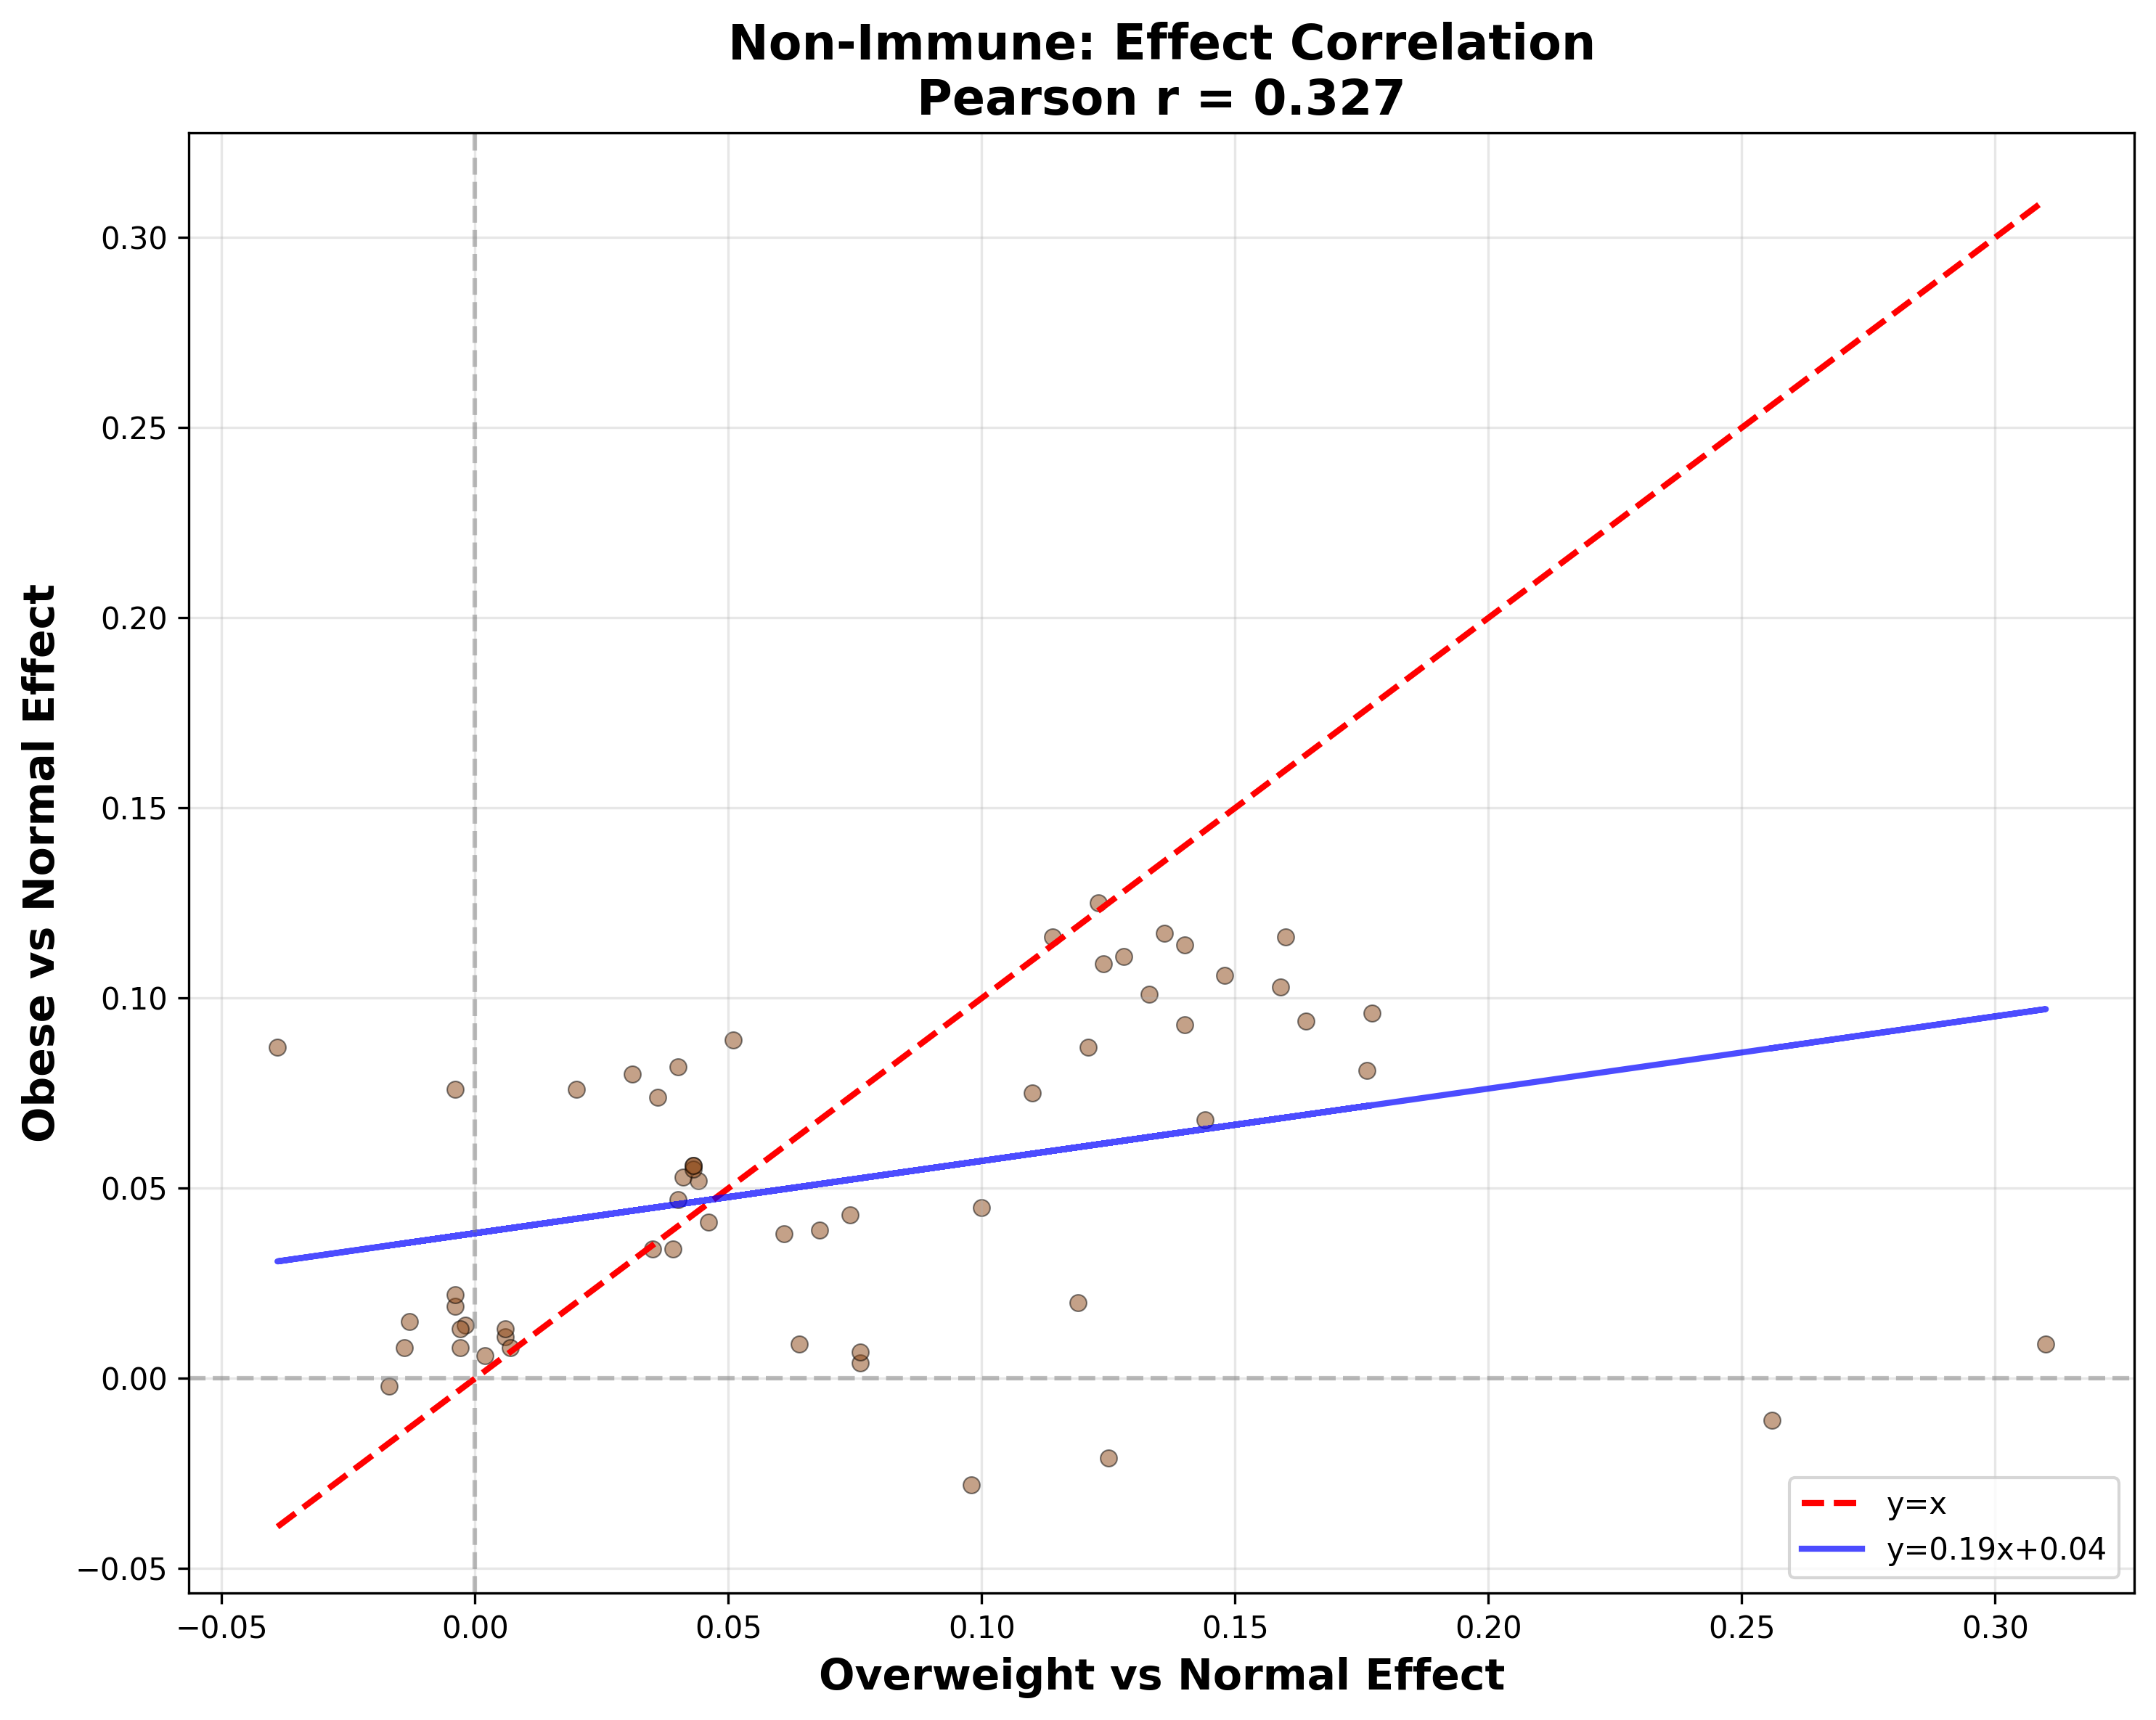


2. SIGNAL-TO-NOISE RATIO

Signal-to-Noise Ratios:
  Overweight - Mean SNR: 1.967, Median: 1.523
  Obese      - Mean SNR: 1.149, Median: 1.088

Features with strong signal (SNR > 2):
  Overweight: 22/57 (38.6%)
  Obese: 12/57 (21.1%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/quantitative_validation/signal_to_noise_ratio.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/quantitative_validation/signal_to_noise_ratio_nonimmune.svg


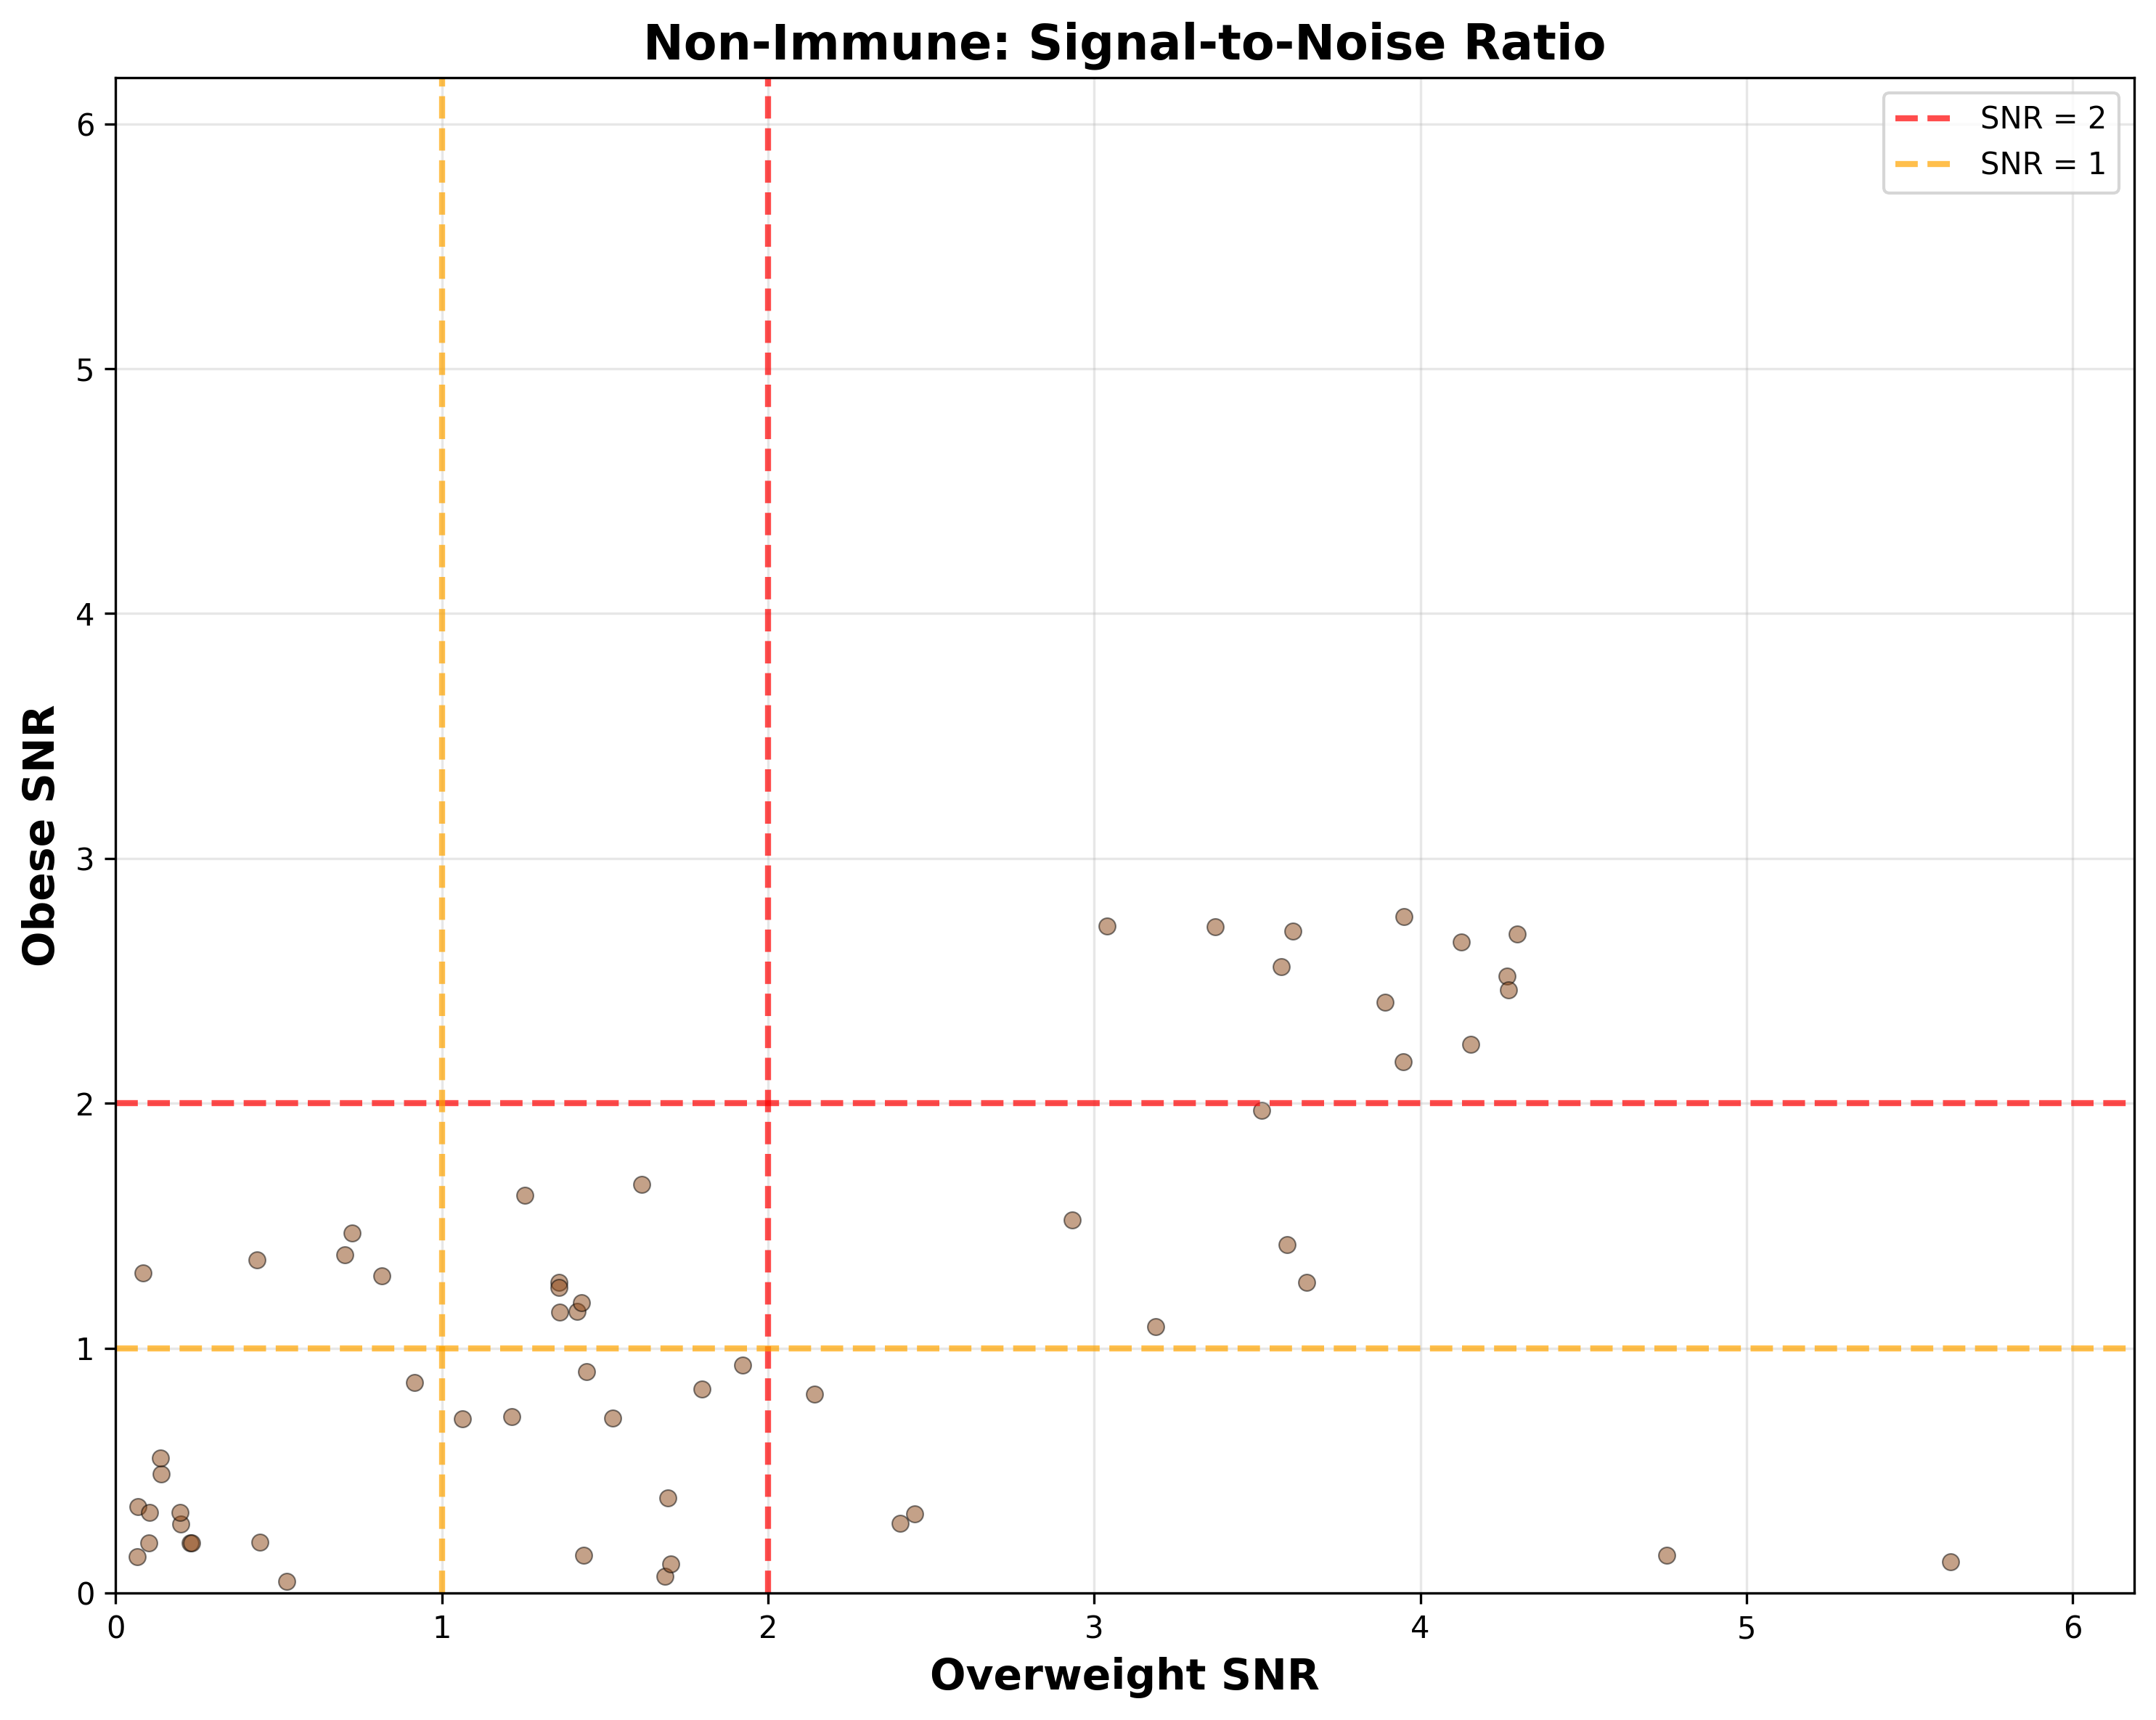


QUANTITATIVE VALIDATION: Non-Immune

CORRELATION:
  Pearson: r = 0.327, p = 1.30e-02
  Spearman: ρ = 0.439, p = 6.26e-04

SIGNAL-TO-NOISE:
  Overweight mean SNR: 1.967
  Obese mean SNR: 1.149
  Strong signals (SNR>2): OW=22, OB=12

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/quantitative_validation/validation_summary.txt

✅ FINISHED: Non-Immune

QUANTITATIVE VALIDATION: Immune Fine

Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/bayesian_results_3group_with_rope.csv

1. CORRELATION ANALYSIS

Pearson correlation: r = 0.524, p = 1.34e-04
Spearman correlation: ρ = 0.704, p = 2.31e-08
  ✅ MODERATE correlation

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/quantitative_validation/correlation_overweight_obese.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/quantitative_validation/correlation_overweight_obese_immune_fine.svg


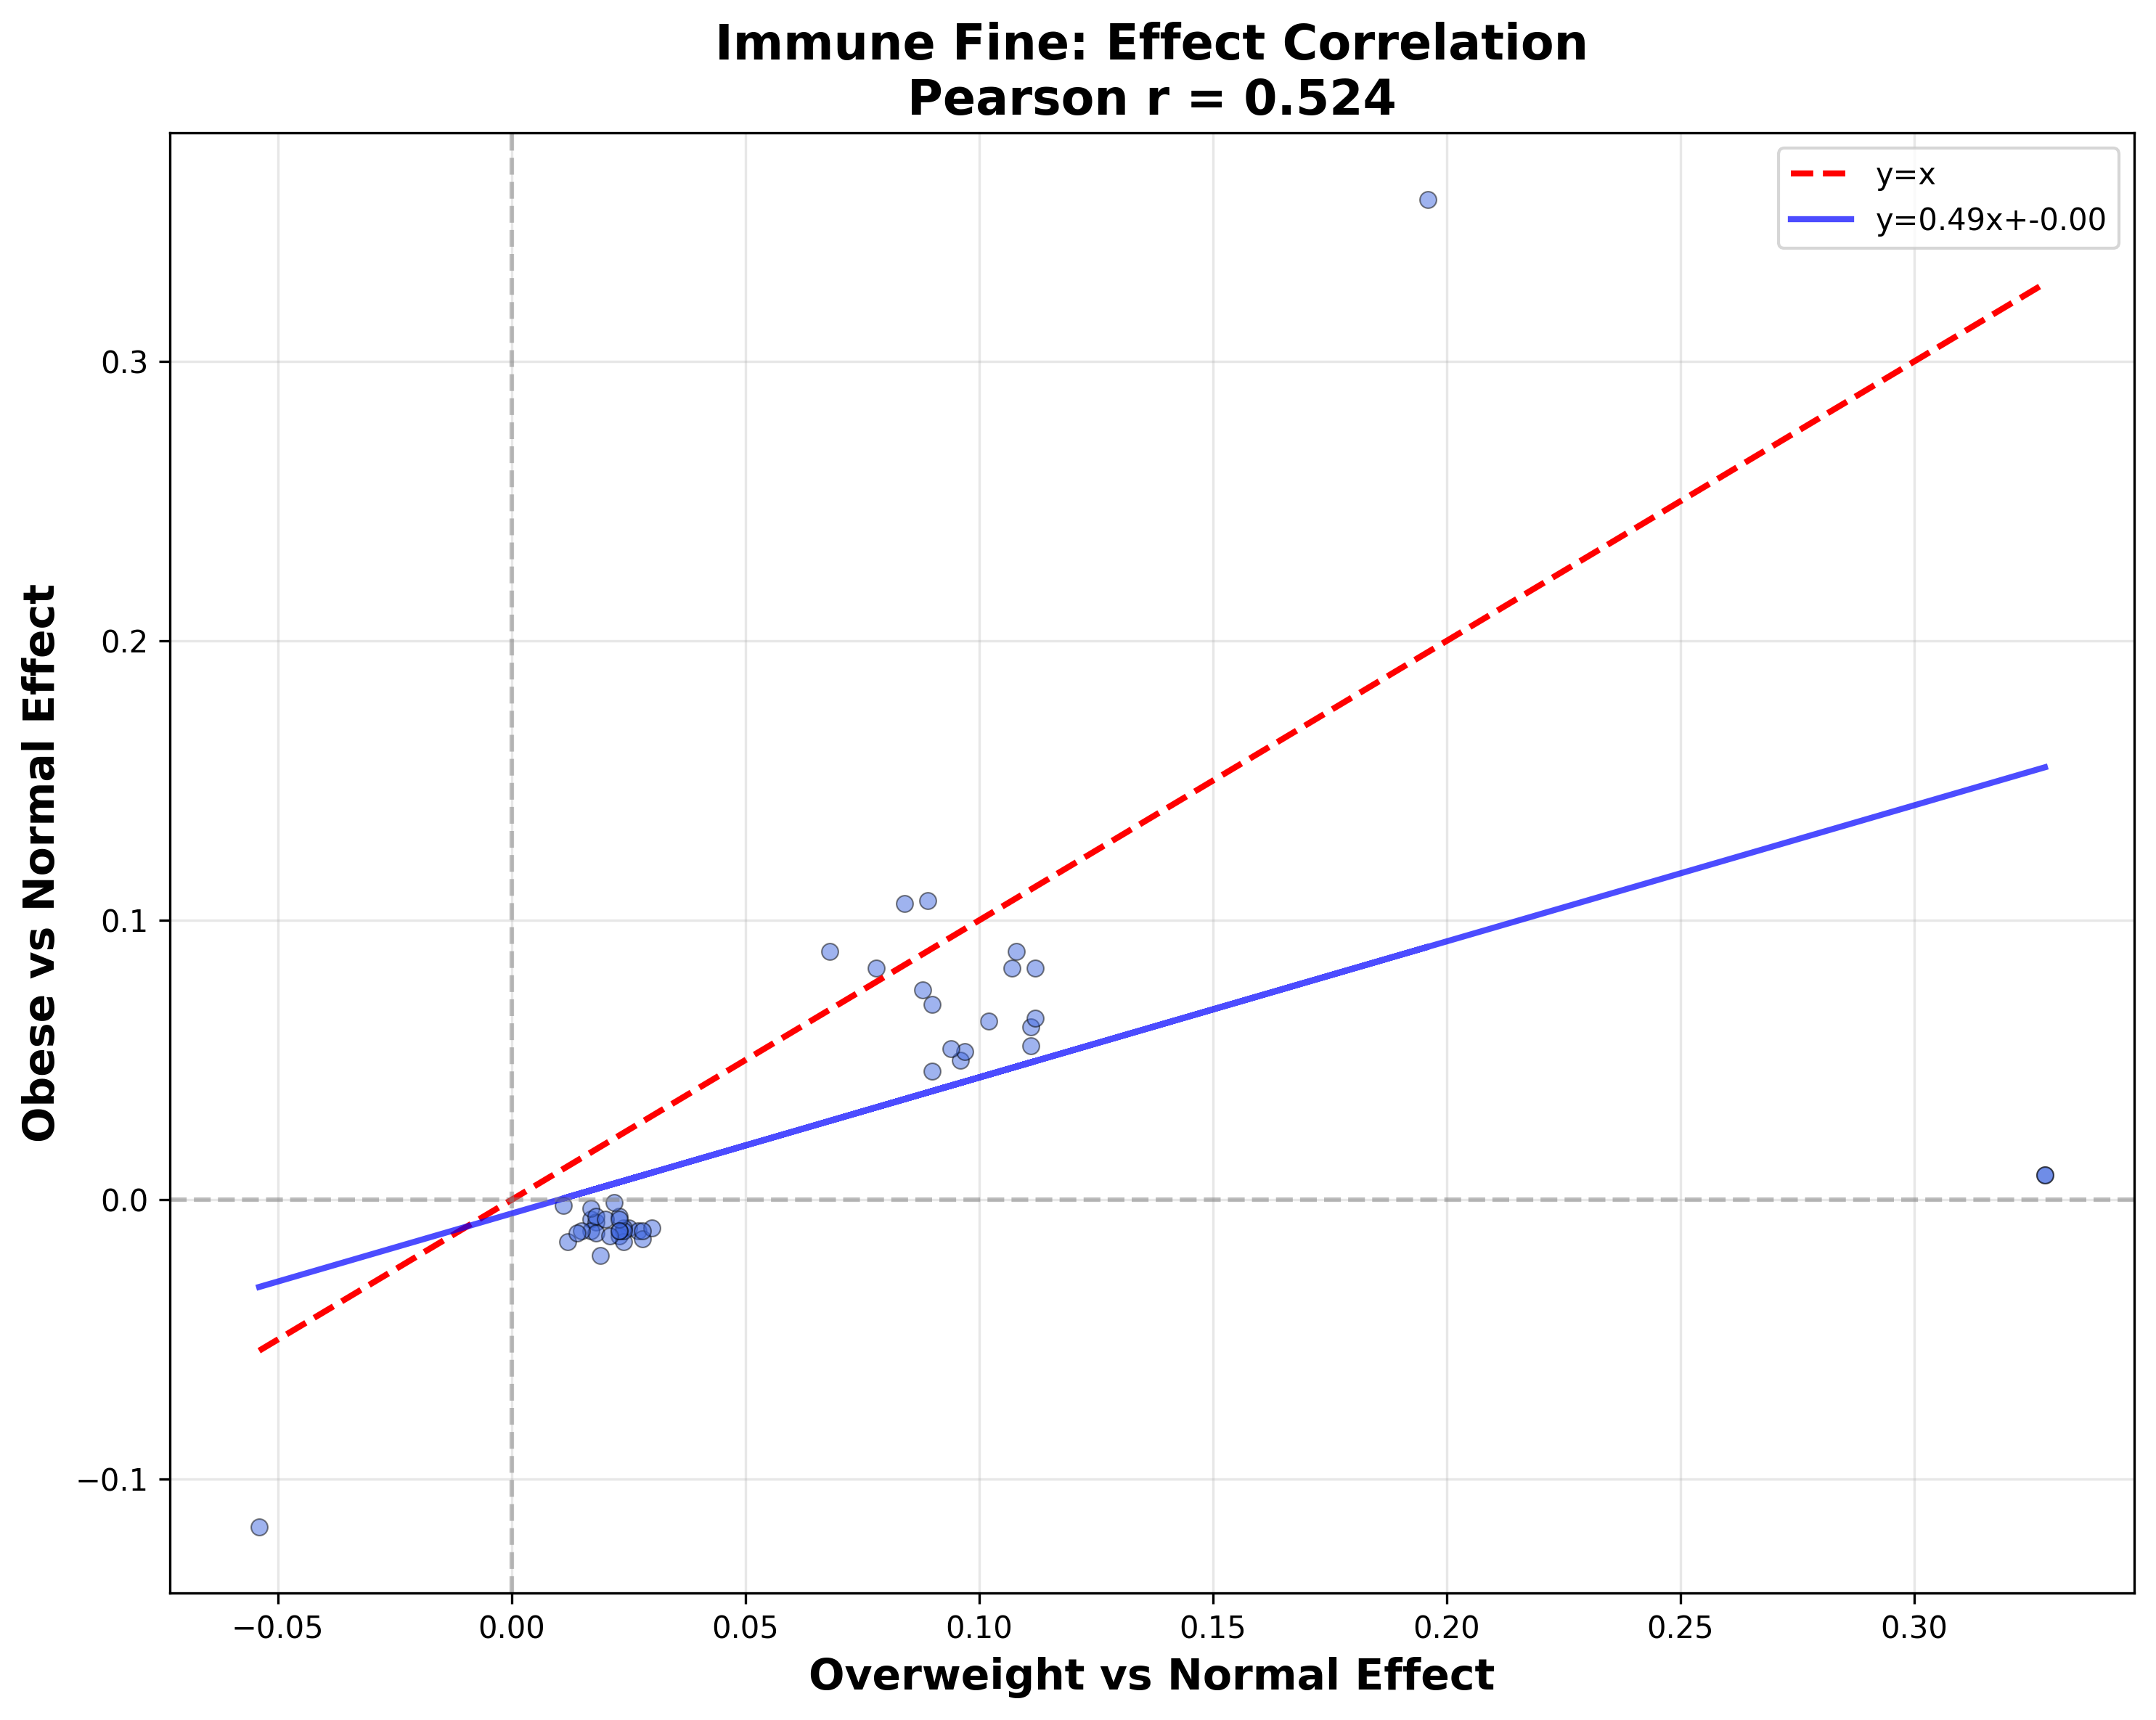


2. SIGNAL-TO-NOISE RATIO

Signal-to-Noise Ratios:
  Overweight - Mean SNR: 1.934, Median: 1.171
  Obese      - Mean SNR: 0.884, Median: 0.472

Features with strong signal (SNR > 2):
  Overweight: 19/48 (39.6%)
  Obese: 3/48 (6.2%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/quantitative_validation/signal_to_noise_ratio.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/quantitative_validation/signal_to_noise_ratio_immune_fine.svg


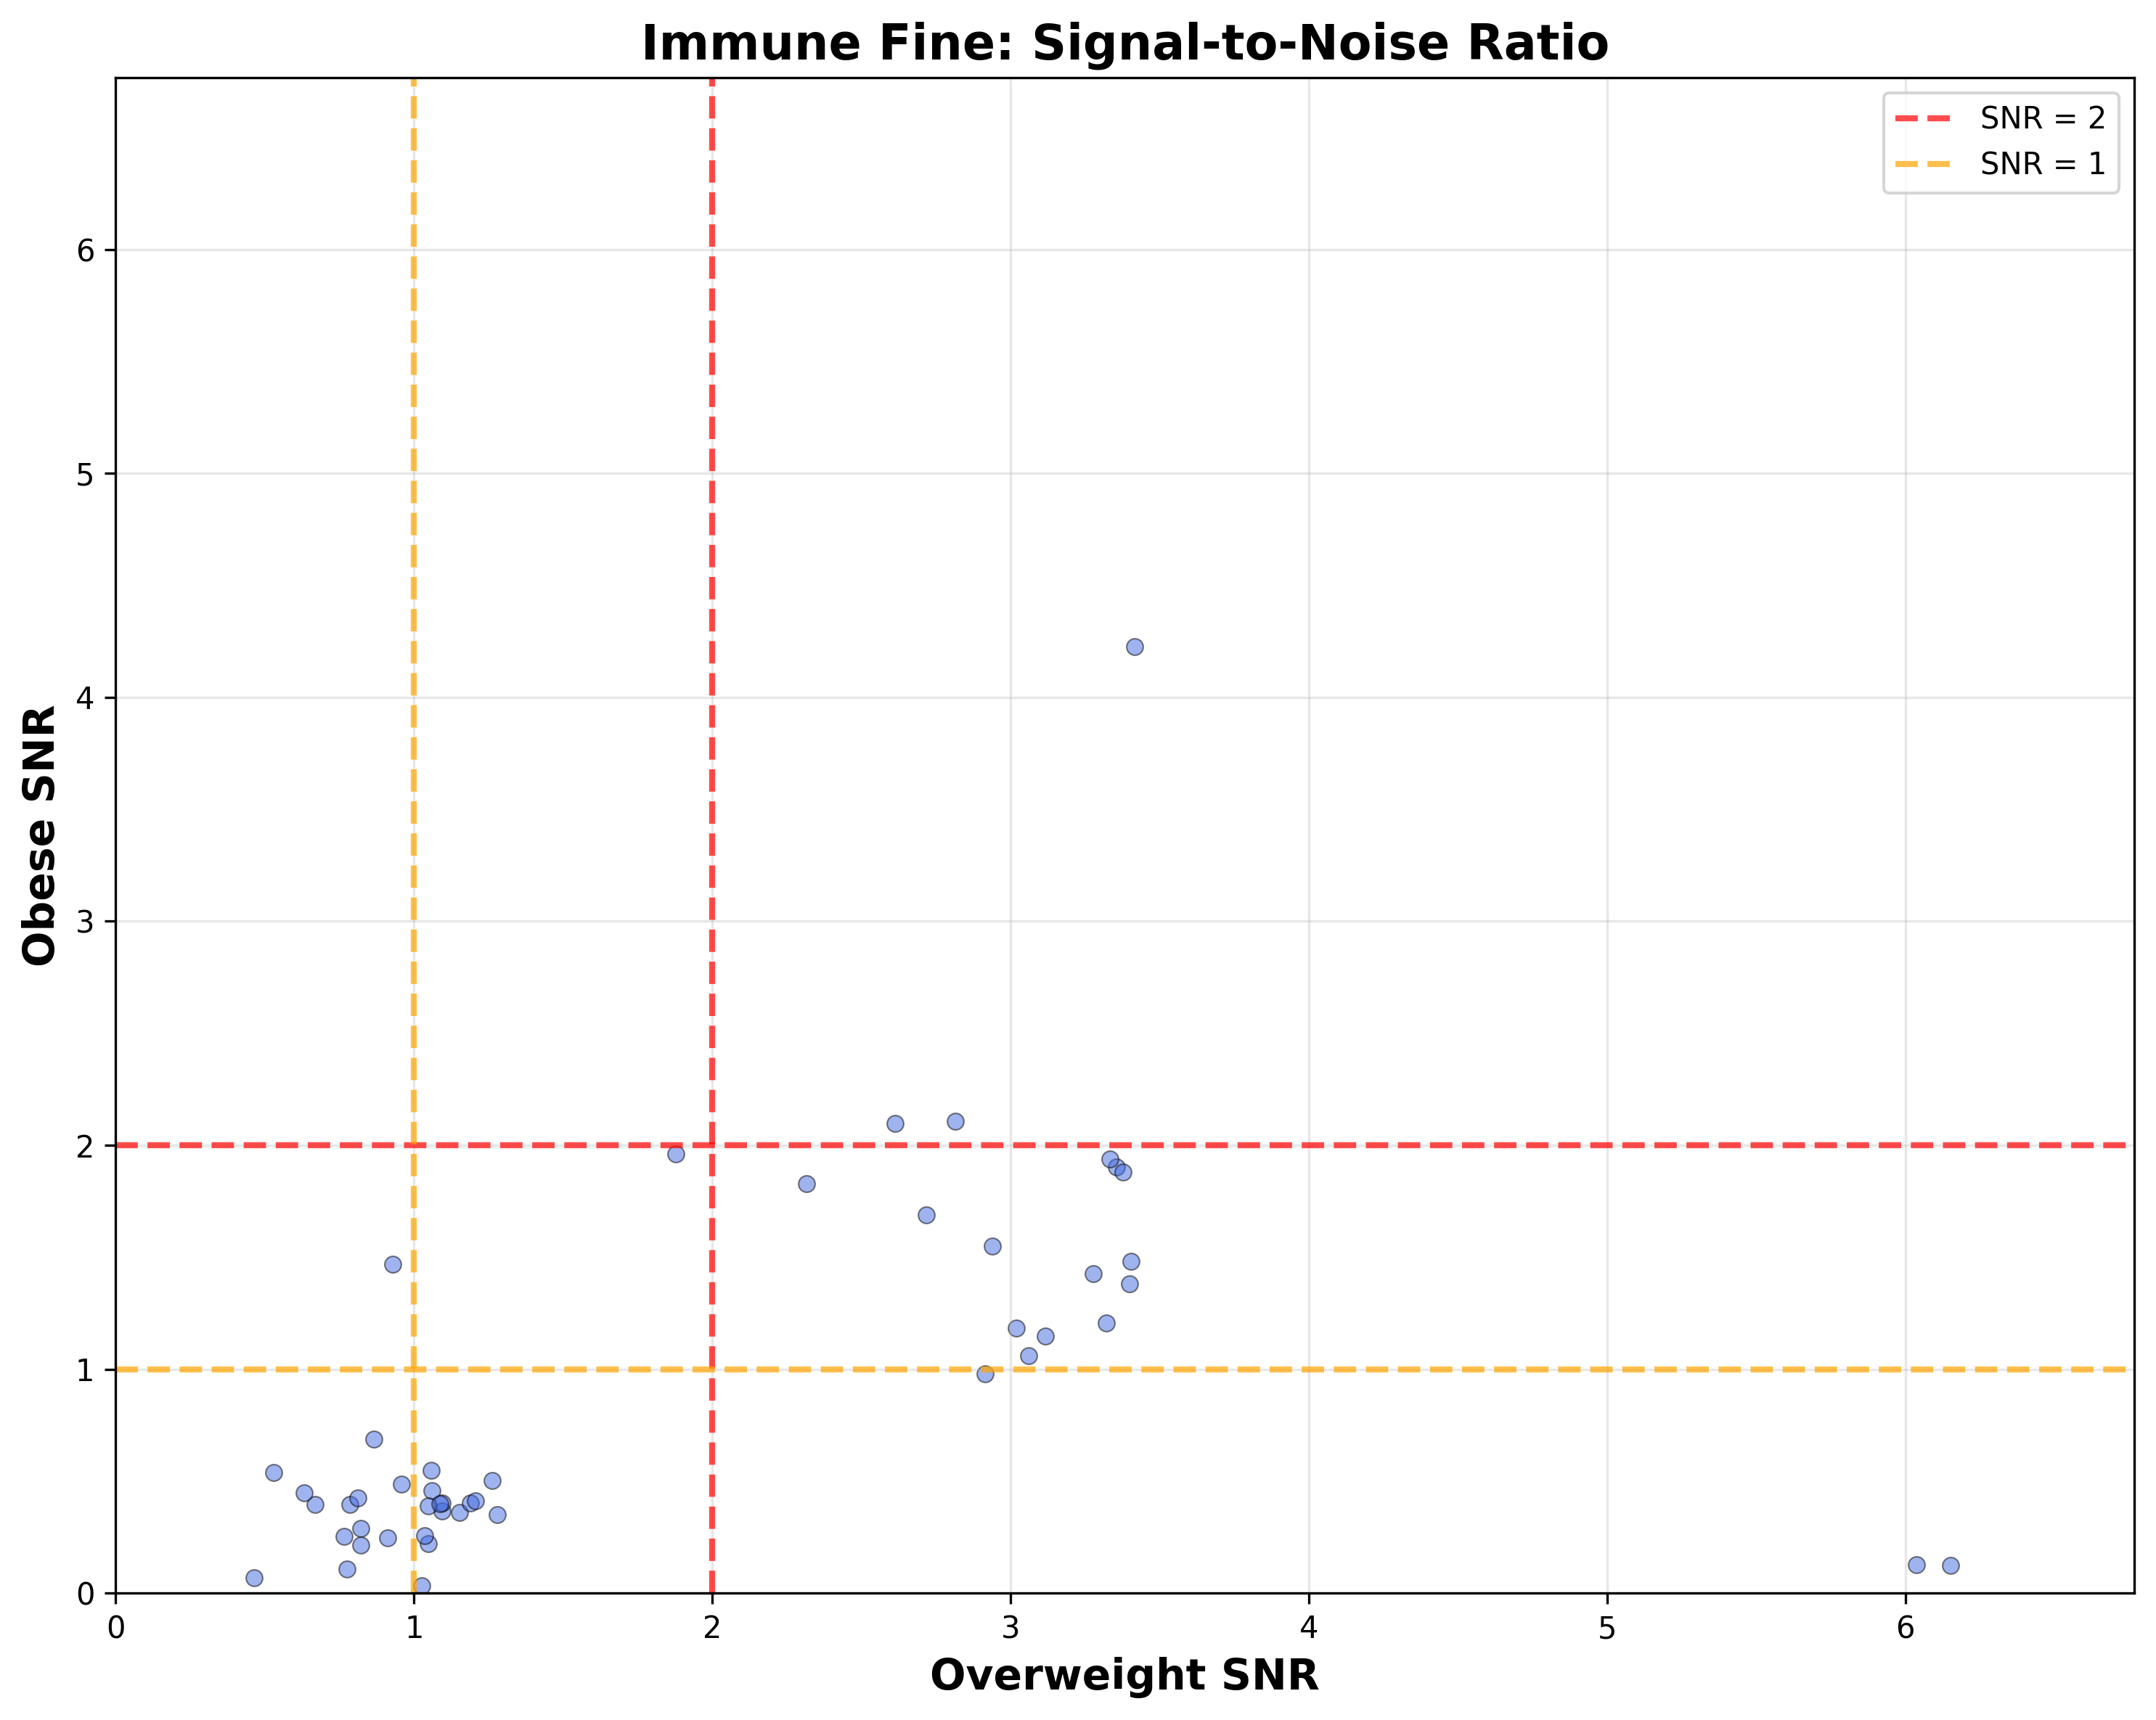


QUANTITATIVE VALIDATION: Immune Fine

CORRELATION:
  Pearson: r = 0.524, p = 1.34e-04
  Spearman: ρ = 0.704, p = 2.31e-08

SIGNAL-TO-NOISE:
  Overweight mean SNR: 1.934
  Obese mean SNR: 0.884
  Strong signals (SNR>2): OW=19, OB=3

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/quantitative_validation/validation_summary.txt

✅ FINISHED: Immune Fine

QUANTITATIVE VALIDATION: Immune Coarse

Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/bayesian_results_3group_with_rope.csv

1. CORRELATION ANALYSIS

Pearson correlation: r = 0.048, p = 8.18e-01
Spearman correlation: ρ = 0.168, p = 4.23e-01
  ⚠️ VERY WEAK correlation

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/quantitative_validation/correlation_overweight_obese.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/quantitative_validation/correlation_overweight_obese_immune_coarse.svg


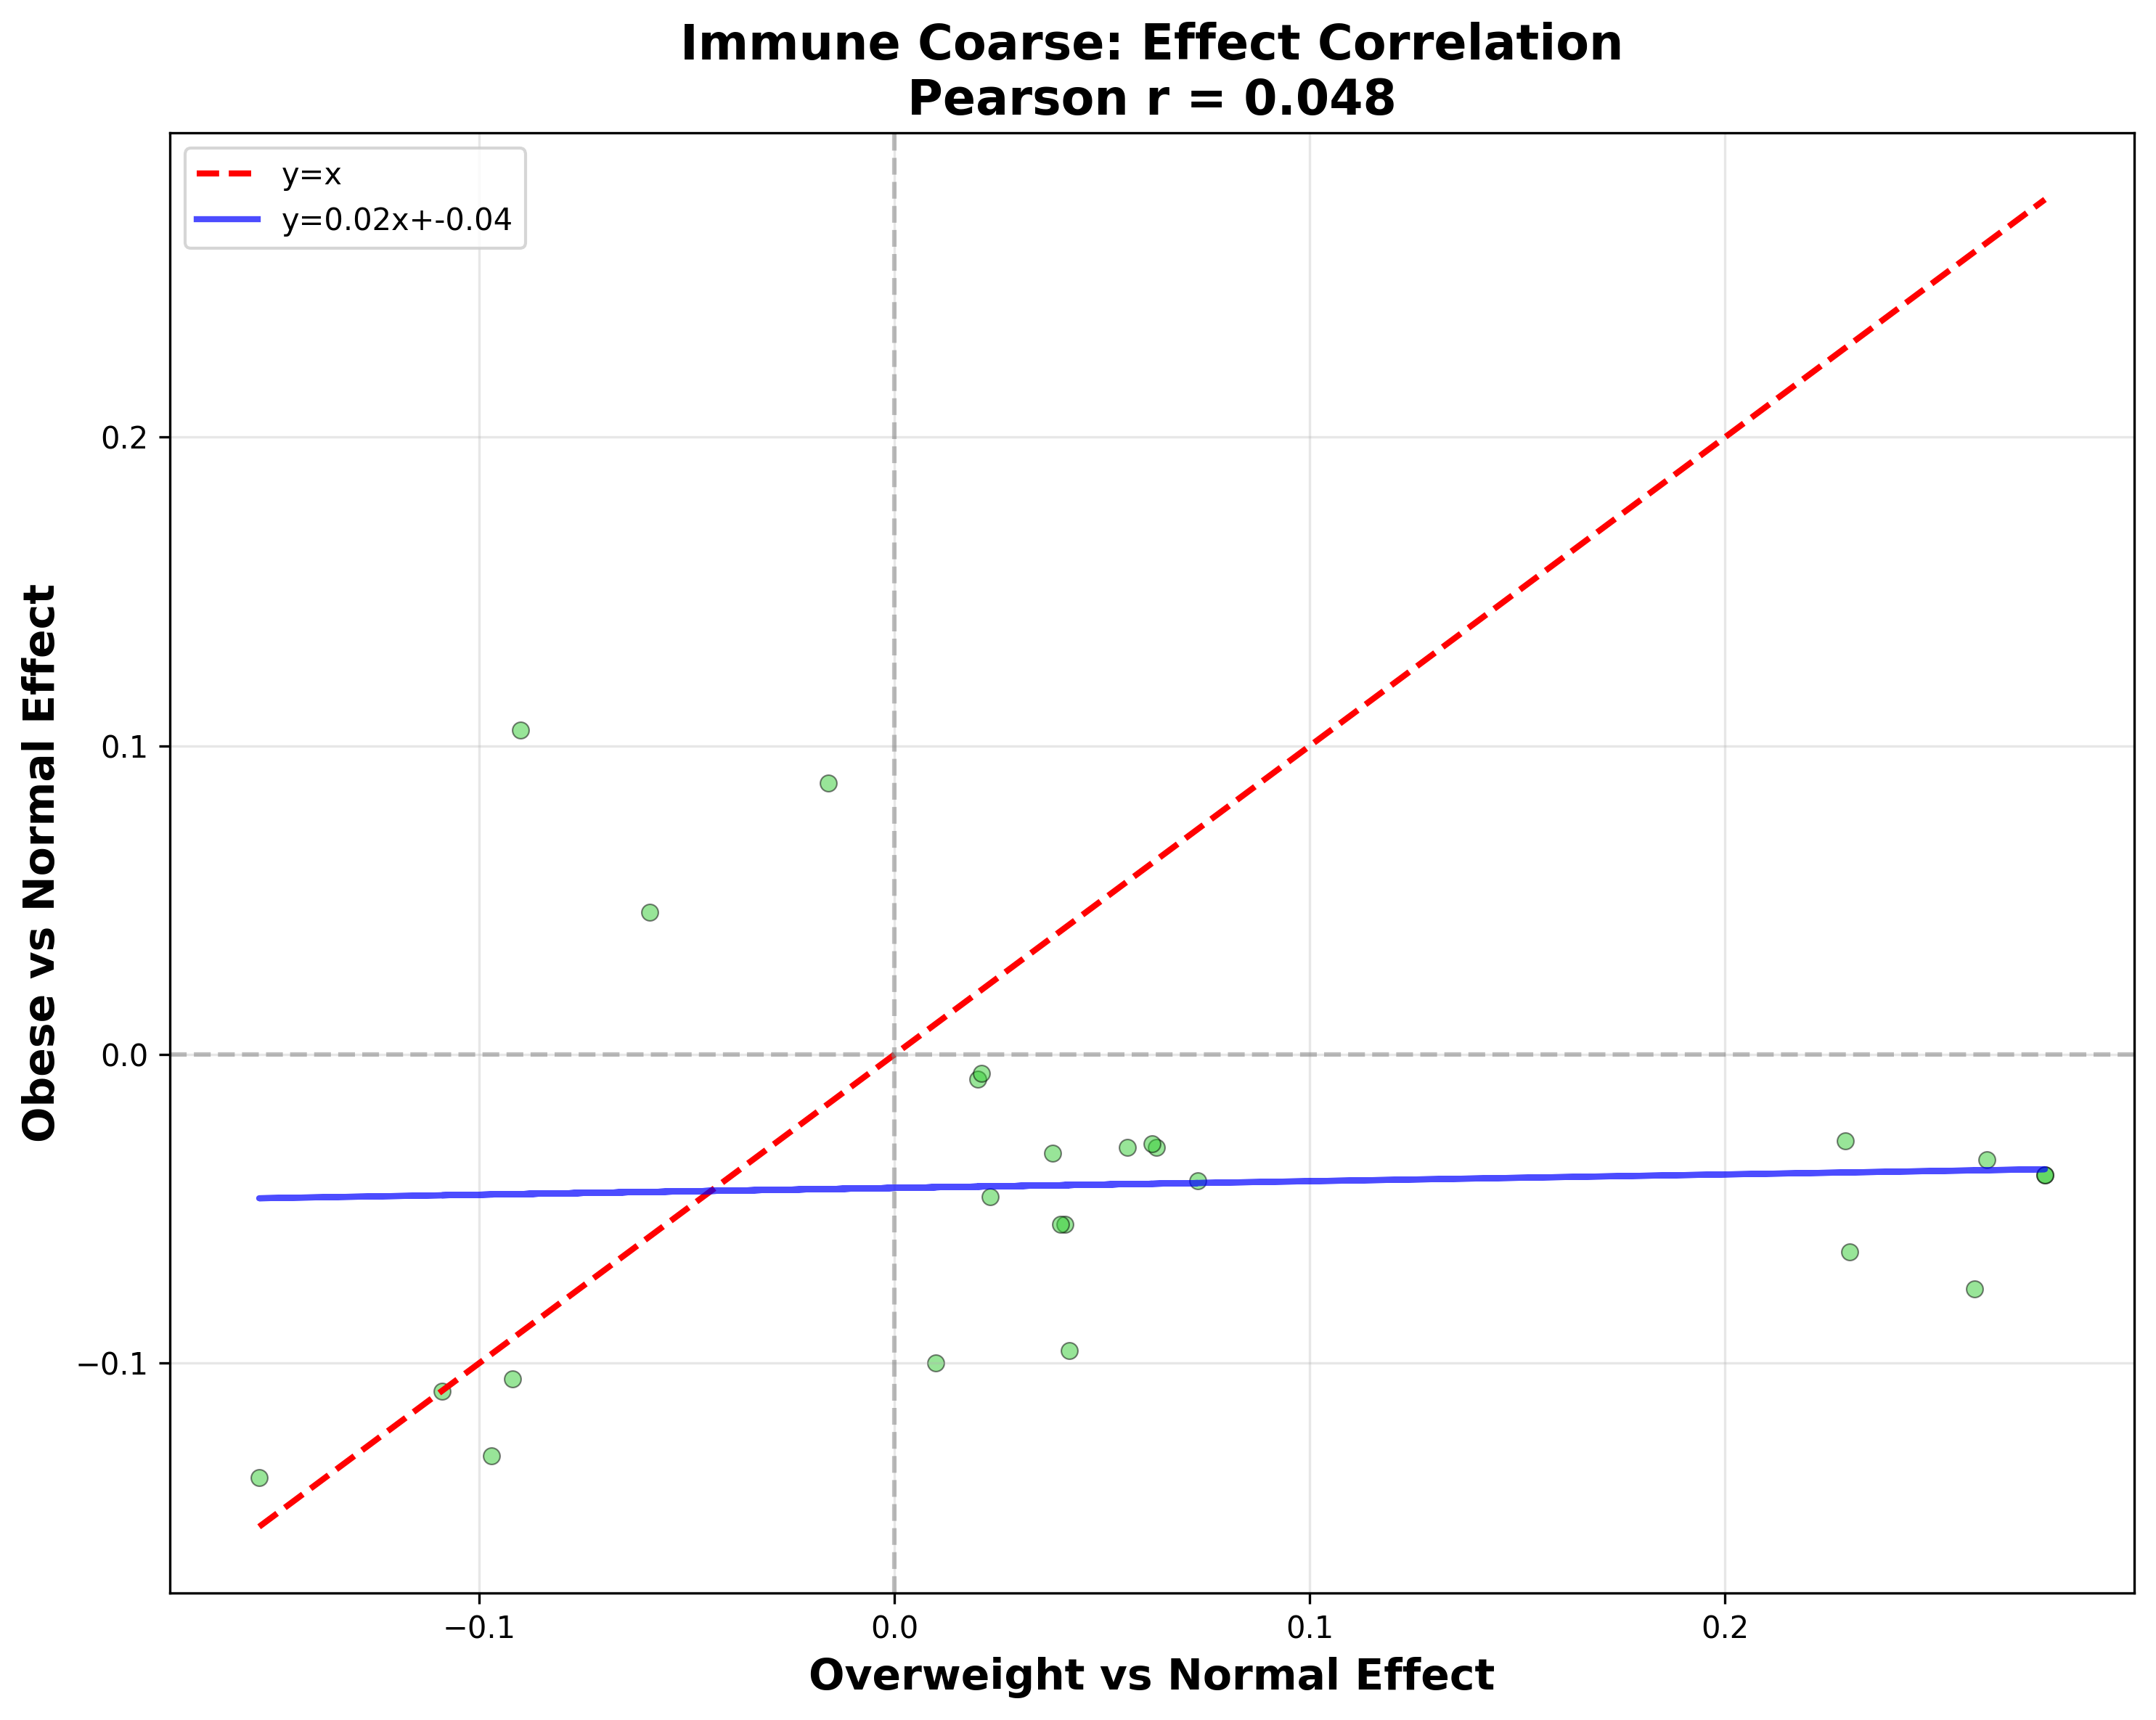


2. SIGNAL-TO-NOISE RATIO

Signal-to-Noise Ratios:
  Overweight - Mean SNR: 1.554, Median: 1.088
  Obese      - Mean SNR: 0.653, Median: 0.611

Features with strong signal (SNR > 2):
  Overweight: 6/25 (24.0%)
  Obese: 0/25 (0.0%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/quantitative_validation/signal_to_noise_ratio.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/quantitative_validation/signal_to_noise_ratio_immune_coarse.svg


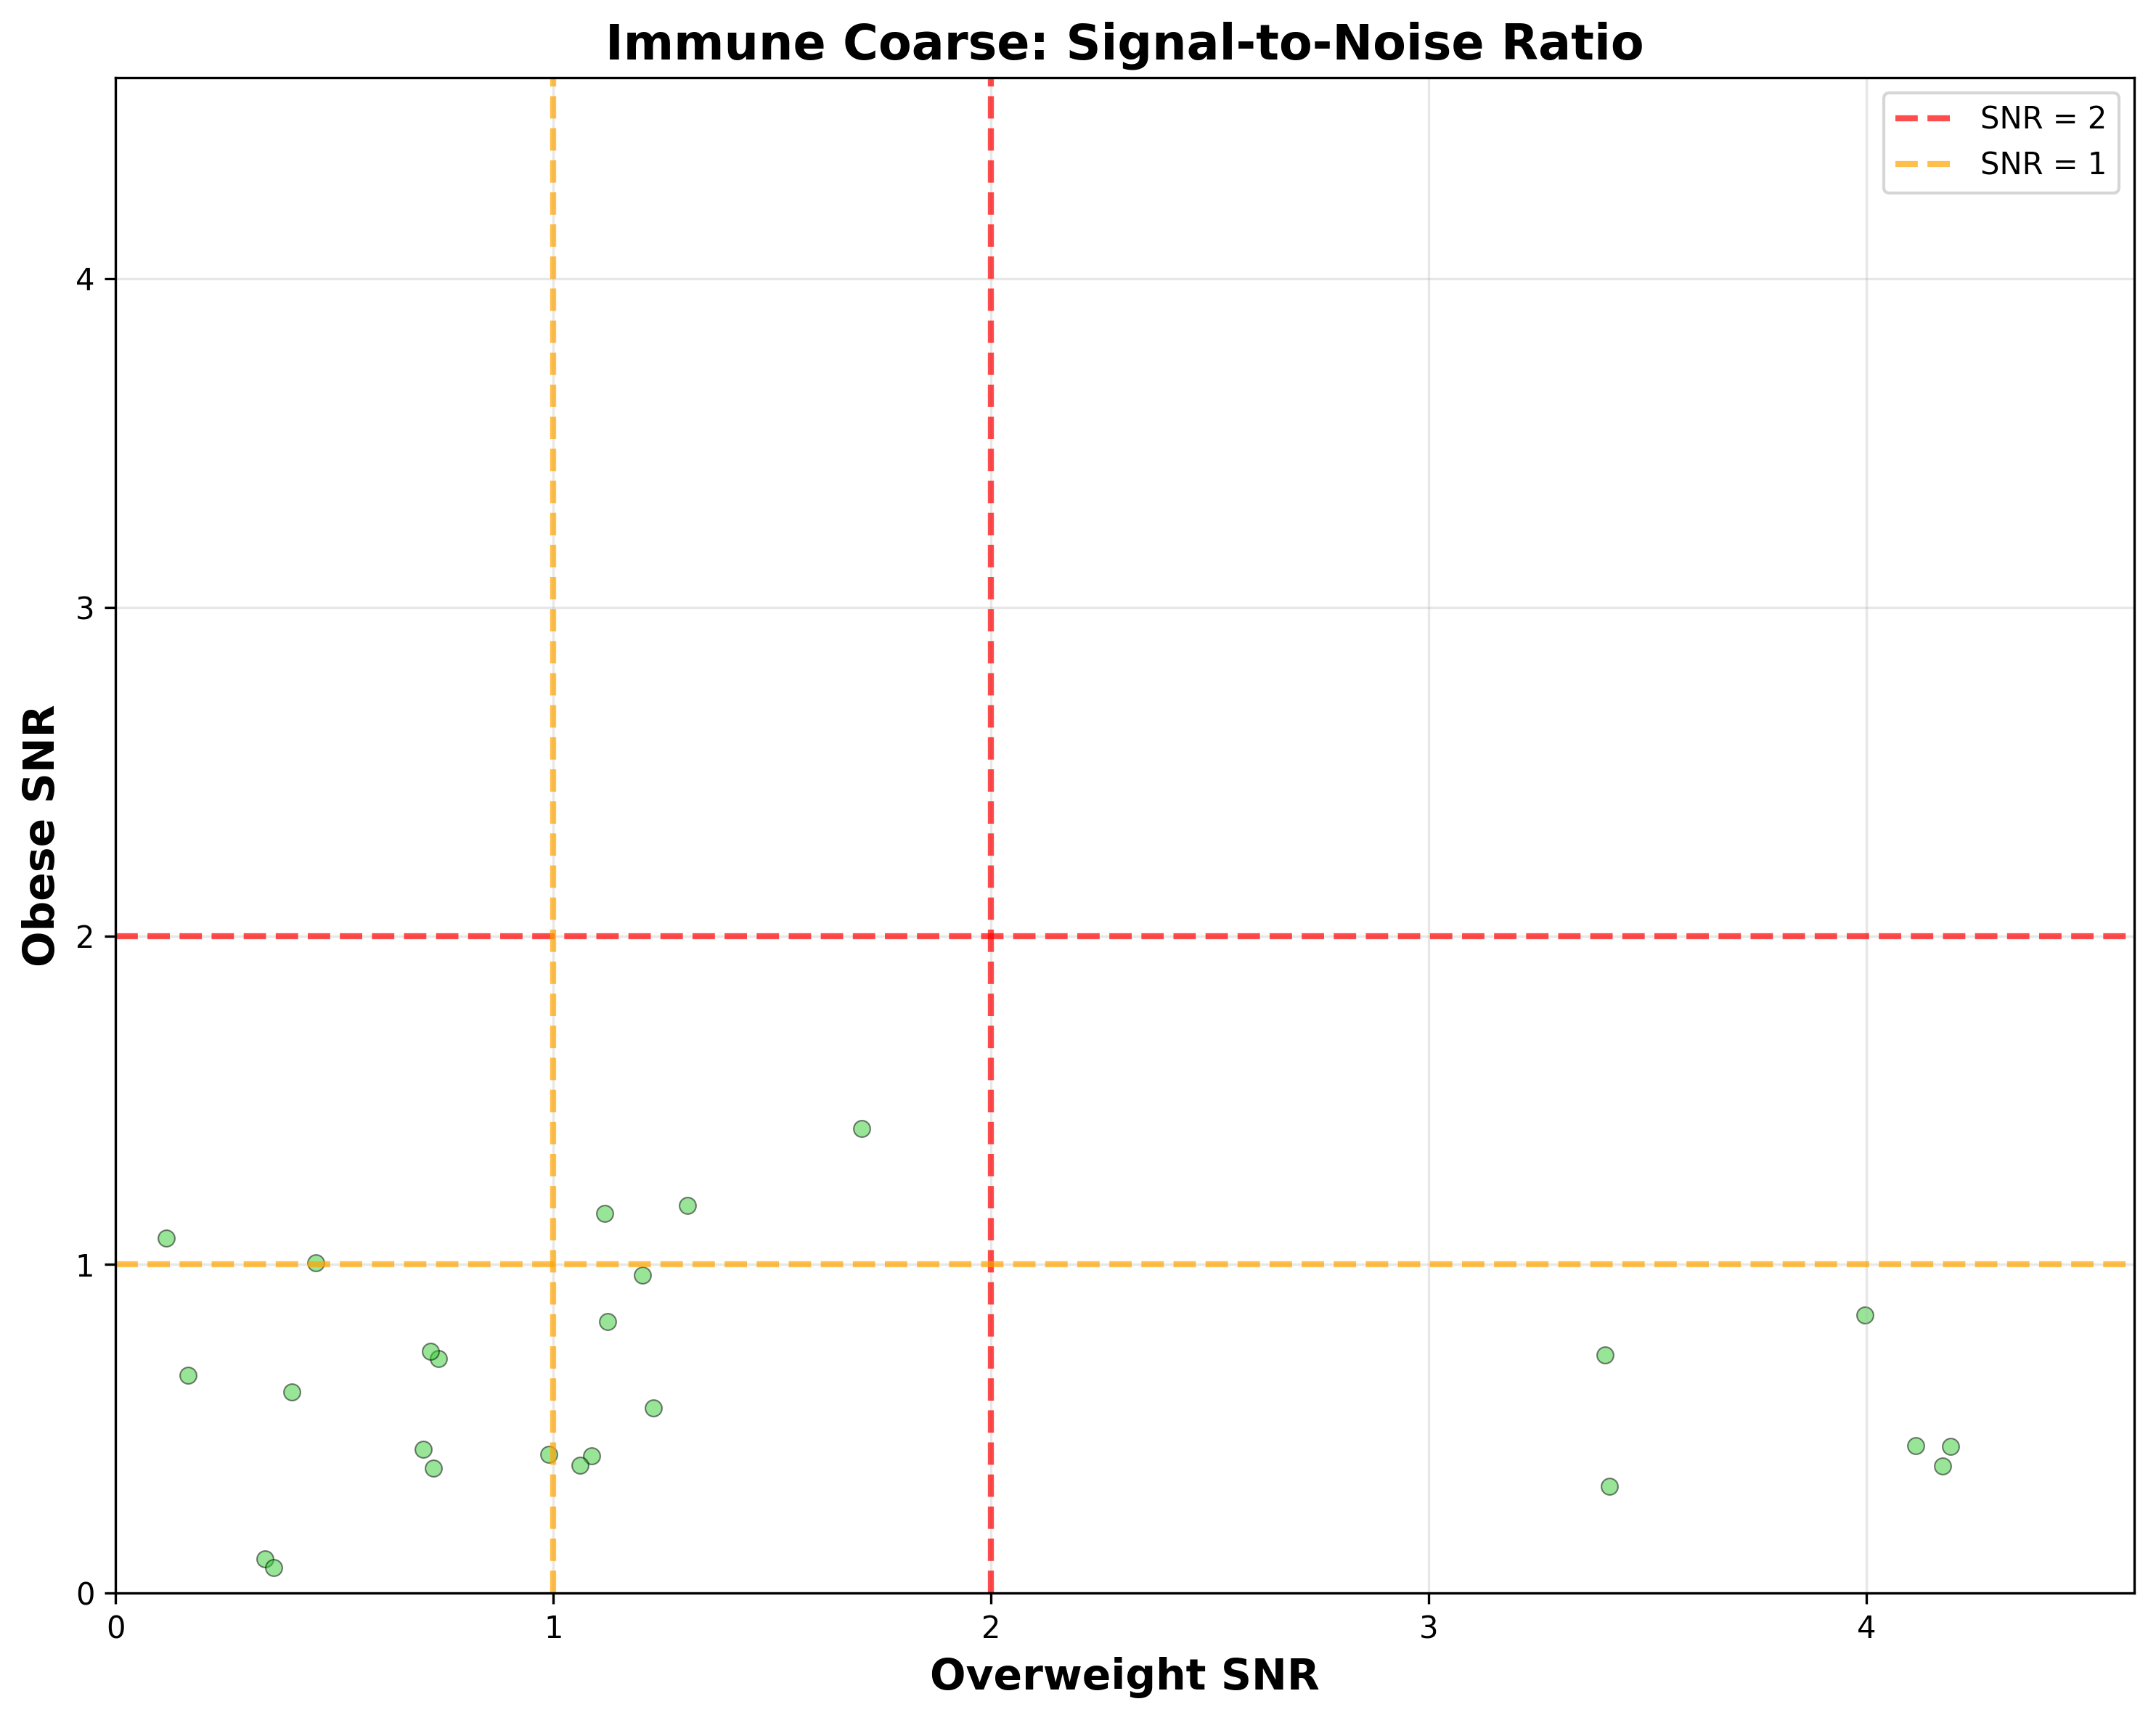


QUANTITATIVE VALIDATION: Immune Coarse

CORRELATION:
  Pearson: r = 0.048, p = 8.18e-01
  Spearman: ρ = 0.168, p = 4.23e-01

SIGNAL-TO-NOISE:
  Overweight mean SNR: 1.554
  Obese mean SNR: 0.653
  Strong signals (SNR>2): OW=6, OB=0

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/quantitative_validation/validation_summary.txt

✅ FINISHED: Immune Coarse

🎉 ALL THREE COMPARTMENTS COMPLETED SUCCESSFULLY!


In [ ]:
#!/usr/bin/env python3
"""
SCRIPT 3: Quantitative Validation (Correlations, SNR)
Runs for all compartments: nonimmune, immune_fine, immune_coarse
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# CONFIGURATION
# ======================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
        'name': 'Non-Immune',
        'color': '#8B4513'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
        'name': 'Immune Fine',
        'color': '#4169E1'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_immune_coarse",
        'name': 'Immune Coarse',
        'color': '#32CD32'
    }
}

FIGURE_DPI = 300

# SVG output configuration
SVG_BASE = f"{BASE}/svg_images"
SVG_SUBFOLDER = "quantitative_validation"

# ======================================================================
# MAIN LOOP (RUN FOR ALL 3 COMPARTMENTS)
# ======================================================================

for COMPARTMENT, info in COMPARTMENTS.items():

    MODEL_DIR = info['dir']
    COMP_NAME = info['name']
    COMP_COLOR = info['color']

    print("\n" + "="*80)
    print(f"QUANTITATIVE VALIDATION: {COMP_NAME}")
    print("="*80)

    out_dir = os.path.join(MODEL_DIR, "quantitative_validation")
    os.makedirs(out_dir, exist_ok=True)

    # Create SVG output directory
    svg_out_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER)
    os.makedirs(svg_out_dir, exist_ok=True)

    results_path = os.path.join(MODEL_DIR, "bayesian_results_3group_with_rope.csv")
    print(f"\nLoading results: {results_path}")
    results = pd.read_csv(results_path)

    # ==================================================================
    # 1. CORRELATION ANALYSIS
    # ==================================================================

    print("\n" + "="*80)
    print("1. CORRELATION ANALYSIS")
    print("="*80)

    ow_effects = results['overweight_vs_normal_mean'].values
    ob_effects = results['obese_vs_normal_mean'].values

    pearson_r, pearson_p = stats.pearsonr(ow_effects, ob_effects)
    spearman_r, spearman_p = stats.spearmanr(ow_effects, ob_effects)

    print(f"\nPearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.2e}")
    print(f"Spearman correlation: ρ = {spearman_r:.3f}, p = {spearman_p:.2e}")

    if pearson_r > 0.8:
        print("   STRONG correlation")
    elif pearson_r > 0.5:
        print("   MODERATE correlation")
    elif pearson_r > 0.3:
        print("   WEAK correlation")
    else:
        print("   VERY WEAK correlation")

    # Scatter plot
    fig, ax = plt.subplots(figsize=(10, 8), dpi=FIGURE_DPI)

    ax.scatter(ow_effects, ob_effects, alpha=0.5, s=30,
               color=COMP_COLOR, edgecolor='black', linewidth=0.5)
    ax.plot([ow_effects.min(), ow_effects.max()],
            [ow_effects.min(), ow_effects.max()],
            'r--', linewidth=2, label='y=x')

    z = np.polyfit(ow_effects, ob_effects, 1)
    p = np.poly1d(z)
    ax.plot(ow_effects, p(ow_effects), "b-", linewidth=2, alpha=0.7,
            label=f'y={z[0]:.2f}x+{z[1]:.2f}')

    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Overweight vs Normal Effect', fontsize=14, fontweight='bold')
    ax.set_ylabel('Obese vs Normal Effect', fontsize=14, fontweight='bold')
    ax.set_title(f'{COMP_NAME}: Effect Correlation\nPearson r = {pearson_r:.3f}',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "correlation_overweight_obese.png")
    plt.savefig(fig_path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"\n Saved: {fig_path}")

    # Save as SVG
    svg_fig_path = os.path.join(svg_out_dir, f"correlation_overweight_obese_{COMPARTMENT}.svg")
    plt.savefig(svg_fig_path, format='svg', bbox_inches='tight')
    print(f" Saved SVG: {svg_fig_path}")

    plt.show()

    # ==================================================================
    # 2. SIGNAL-TO-NOISE RATIO
    # ==================================================================

    print("\n" + "="*80)
    print("2. SIGNAL-TO-NOISE RATIO")
    print("="*80)

    ow_hdi_width = results['overweight_vs_normal_hdi_high'] - results['overweight_vs_normal_hdi_low']
    ob_hdi_width = results['obese_vs_normal_hdi_high'] - results['obese_vs_normal_hdi_low']

    ow_post_sd = ow_hdi_width / 3.92
    ob_post_sd = ob_hdi_width / 3.92

    ow_snr = np.abs(ow_effects) / ow_post_sd
    ob_snr = np.abs(ob_effects) / ob_post_sd

    print(f"\nSignal-to-Noise Ratios:")
    print(f"  Overweight - Mean SNR: {ow_snr.mean():.3f}, Median: {np.median(ow_snr):.3f}")
    print(f"  Obese      - Mean SNR: {ob_snr.mean():.3f}, Median: {np.median(ob_snr):.3f}")

    high_snr_ow = (ow_snr > 2).sum()
    high_snr_ob = (ob_snr > 2).sum()

    print(f"\nFeatures with strong signal (SNR > 2):")
    print(f"  Overweight: {high_snr_ow}/{len(results)} ({high_snr_ow/len(results)*100:.1f}%)")
    print(f"  Obese: {high_snr_ob}/{len(results)} ({high_snr_ob/len(results)*100:.1f}%)")

    # SNR scatter plot
    fig, ax = plt.subplots(figsize=(10, 8), dpi=FIGURE_DPI)

    ax.scatter(ow_snr, ob_snr, alpha=0.5, s=30,
               color=COMP_COLOR, edgecolor='black', linewidth=0.5)
    ax.axhline(2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 2')
    ax.axvline(2, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(1, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 1')
    ax.axvline(1, color='orange', linestyle='--', linewidth=2, alpha=0.7)

    ax.set_xlabel('Overweight SNR', fontsize=14, fontweight='bold')
    ax.set_ylabel('Obese SNR', fontsize=14, fontweight='bold')
    ax.set_title(f'{COMP_NAME}: Signal-to-Noise Ratio',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, max(ow_snr.max(), ob_snr.max()) * 1.1])
    ax.set_ylim([0, max(ow_snr.max(), ob_snr.max()) * 1.1])

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "signal_to_noise_ratio.png")
    plt.savefig(fig_path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"\n Saved: {fig_path}")

    # Save as SVG
    svg_fig_path = os.path.join(svg_out_dir, f"signal_to_noise_ratio_{COMPARTMENT}.svg")
    plt.savefig(svg_fig_path, format='svg', bbox_inches='tight')
    print(f" Saved SVG: {svg_fig_path}")

    plt.show()

    # ==================================================================
    # Save summary
    # ==================================================================

    report = []
    report.append("="*80)
    report.append(f"QUANTITATIVE VALIDATION: {COMP_NAME}")
    report.append("="*80)
    report.append("")
    report.append("CORRELATION:")
    report.append(f"  Pearson: r = {pearson_r:.3f}, p = {pearson_p:.2e}")
    report.append(f"  Spearman: ρ = {spearman_r:.3f}, p = {spearman_p:.2e}")
    report.append("")
    report.append("SIGNAL-TO-NOISE:")
    report.append(f"  Overweight mean SNR: {ow_snr.mean():.3f}")
    report.append(f"  Obese mean SNR: {ob_snr.mean():.3f}")
    report.append(f"  Strong signals (SNR>2): OW={high_snr_ow}, OB={high_snr_ob}")
    report.append("")

    report_text = "\n".join(report)
    print("\n" + report_text)

    report_path = os.path.join(out_dir, "validation_summary.txt")
    with open(report_path, 'w') as f:
        f.write(report_text)
    print(f" Saved: {report_path}")

    print("\n FINISHED:", COMP_NAME)

print("\n ALL THREE COMPARTMENTS COMPLETED SUCCESSFULLY!")